## Task 1: HR Data Preparation

### Data Loading and Initial Inspection

First, we'll load the dataset into a Pandas DataFrame and perform an initial check for missing values and duplicate rows. We will also convert the `Hire_Date` column to a datetime object.

In [18]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Extended_Employee_Performance_and_Productivity_Data.csv')

# Initial inspection
print('Initial DataFrame Info:')
df.info()
print(f'\nNumber of duplicate rows: {df.duplicated().sum()}')

# Convert 'Hire_Date' to datetime
df['Hire_Date'] = pd.to_datetime(df['Hire_Date'])
print("\n'Hire_Date' converted to datetime:")
df.info()

# Display the first 5 rows
print('\nFirst 5 rows of the DataFrame:')
display(df.head())

Initial DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


### Categorical Consistency Check



In [19]:
# Check unique values in categorical columns
for col in ['Department', 'Gender', 'Job_Title', 'Education_Level']:
    print(f"\nUnique values for '{col}':")
    print(df[col].unique())


Unique values for 'Department':
['IT' 'Finance' 'Customer Support' 'Engineering' 'Marketing' 'HR'
 'Operations' 'Sales' 'Legal']

Unique values for 'Gender':
['Male' 'Female' 'Other']

Unique values for 'Job_Title':
['Specialist' 'Developer' 'Analyst' 'Manager' 'Technician' 'Engineer'
 'Consultant']

Unique values for 'Education_Level':
['High School' 'Bachelor' 'Master' 'PhD']


### Feature Engineering

We will create several new features to enhance our analysis:

1.  **`Years_Since_Last_Promotion`**: This feature will approximate the years since an employee's last promotion. If `Promotions` is 0, we'll use `Years_At_Company`; otherwise, we'll assume 0 years since the last promotion.
2.  **`Salary_Relative_To_Team_Average`**: This will compare an individual's salary to the average salary within their department.
3.  **`Performance_Level`**: A categorical representation of `Performance_Score` to simplify analysis (Low, Medium, High).
4.  **`Engagement_Risk_Score`**: A composite score based on `Employee_Satisfaction_Score`, `Overtime_Hours`, and `Sick_Days` to identify potentially disengaged employees.

In [20]:
import numpy as np

# 1. Years_Since_Last_Promotion
df['Years_Since_Last_Promotion'] = np.where(df['Promotions'] == 0, df['Years_At_Company'], 0)

# 2. Salary_Relative_To_Team_Average
df['Department_Average_Salary'] = df.groupby('Department')['Monthly_Salary'].transform('mean')
df['Salary_Relative_To_Team_Average'] = df['Monthly_Salary'] - df['Department_Average_Salary']

# 3. Performance_Level
df['Performance_Level'] = pd.cut(df['Performance_Score'], bins=[0, 2, 4, 5], labels=['Low', 'Medium', 'High'], right=True)

# 4. Engagement_Risk_Score (higher score indicates higher risk)
# Inverse satisfaction score, direct overtime and sick days
df['Engagement_Risk_Score'] = (5 - df['Employee_Satisfaction_Score']) / 5 + \
                              df['Overtime_Hours'] / df['Overtime_Hours'].max() + \
                              df['Sick_Days'] / df['Sick_Days'].max()

print('New features created and added to DataFrame.')
display(df[['Employee_ID', 'Department', 'Years_At_Company', 'Promotions', 'Years_Since_Last_Promotion',
            'Monthly_Salary', 'Department_Average_Salary', 'Salary_Relative_To_Team_Average',
            'Performance_Score', 'Performance_Level', 'Employee_Satisfaction_Score', 'Overtime_Hours',
            'Sick_Days', 'Engagement_Risk_Score']].head())

New features created and added to DataFrame.


,Employee_ID,Department,Years_At_Company,Promotions,Years_Since_Last_Promotion,Monthly_Salary,Department_Average_Salary,Salary_Relative_To_Team_Average,Performance_Score,Performance_Level,Employee_Satisfaction_Score,Overtime_Hours,Sick_Days,Engagement_Risk_Score
0,1,IT,2,0,2,6750.0,6414.598868,335.401132,5,High,2.63,22,2,1.375478
1,2,Finance,0,2,0,7500.0,6398.575893,1101.424107,5,High,1.72,13,14,2.104276
2,3,Finance,8,0,8,5850.0,6398.575893,-548.575893,3,Medium,3.17,6,3,0.787182
3,4,Customer Support,7,1,0,4800.0,6403.881792,-1603.881792,2,Low,1.86,28,12,2.450660
4,5,Engineering,3,1,0,4800.0,6417.246258,-1617.246258,2,Low,1.25,29,13,2.678571


## Task 2: Workforce Exploratory Analysis

### Attrition Rates by Department

To understand attrition patterns, we will calculate the attrition rate for each department and visualize these rates using a bar plot.

Attrition Rates by Department:


Resigned,False,True,Attrition_Rate
Department,,,
Finance,0.894643,0.105357,10.535714
HR,0.897354,0.102646,10.264599
Legal,0.897823,0.102177,10.217665
Marketing,0.899697,0.100303,10.030314
Operations,0.899741,0.100259,10.025937
Sales,0.900737,0.099263,9.926272
Customer Support,0.901223,0.098777,9.877654
Engineering,0.903523,0.096477,9.647682
IT,0.904411,0.095589,9.558890


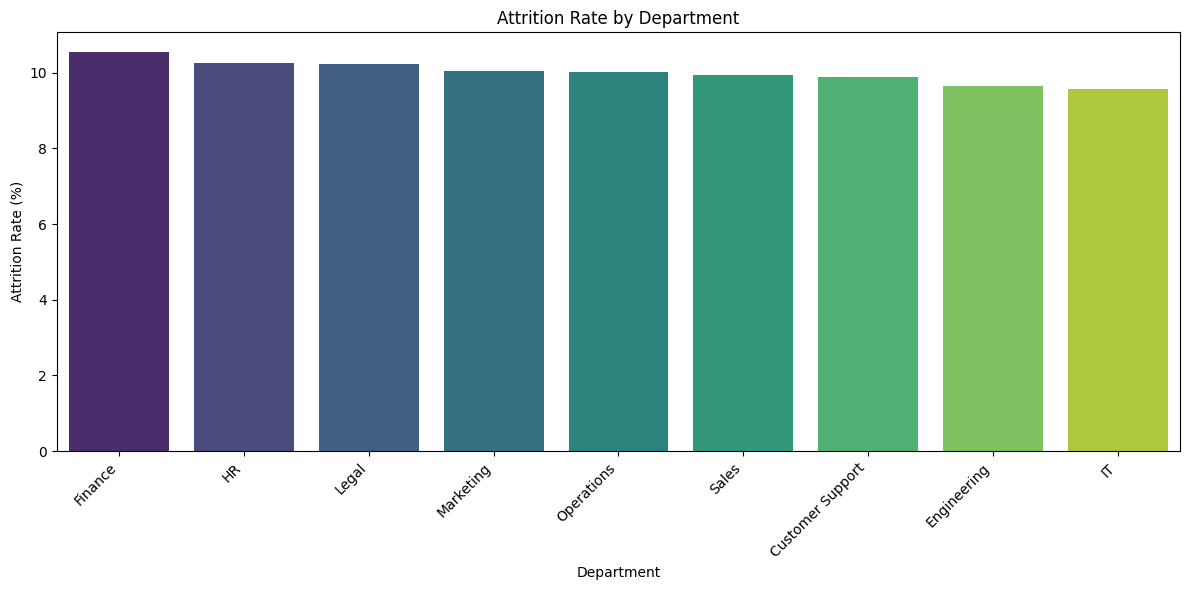

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate attrition rates by department
attrition_by_department = df.groupby('Department')['Resigned'].value_counts(normalize=True).unstack()
attrition_by_department['Attrition_Rate'] = attrition_by_department[True] * 100
attrition_by_department = attrition_by_department.sort_values(by='Attrition_Rate', ascending=False)

print("Attrition Rates by Department:")
display(attrition_by_department)

# Visualize attrition rates
plt.figure(figsize=(12, 6))
sns.barplot(x=attrition_by_department.index, y=attrition_by_department['Attrition_Rate'], palette='viridis', hue=attrition_by_department.index, legend=False)
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Salary Distribution by Gender and Age Group


Salary Distribution by Gender:


,Gender,mean,median,std
0,Female,6404.986354,6500.0,1371.548046
1,Male,6400.481980,6500.0,1372.071836
2,Other,6414.768145,6500.0,1389.561864


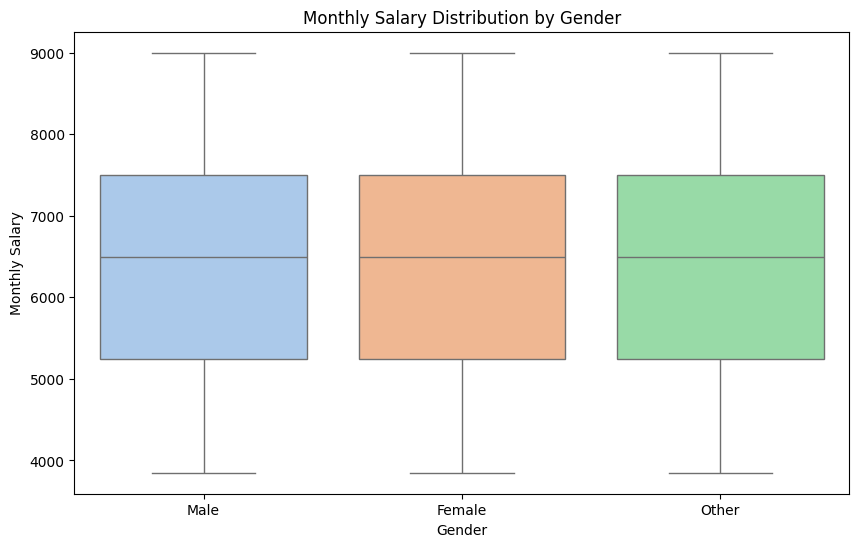


Salary Distribution by Age Group:


,Age_Group,mean,median,std
0,20-29,6400.378196,6500.0,1377.538244
1,30-39,6399.789908,6500.0,1370.015261
2,40-49,6404.698561,6500.0,1376.452269
3,50-59,6402.854872,6500.0,1367.167043
4,60+,6449.013807,6600.0,1371.247126


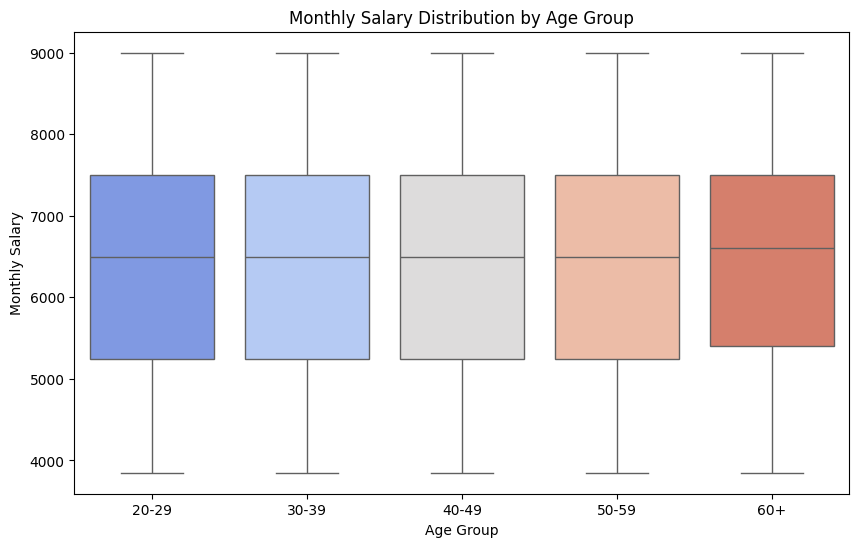

In [25]:
# 1. Salary Distribution by Gender
print("Salary Distribution by Gender:")
salary_by_gender = df.groupby('Gender')['Monthly_Salary'].agg(['mean', 'median', 'std']).reset_index()
display(salary_by_gender)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Monthly_Salary', data=df, palette='pastel', hue='Gender', legend=False)
plt.title('Monthly Salary Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Monthly Salary')
plt.show()

# 2. Salary Distribution by Age Group
# Create Age Groups
age_bins = [20, 30, 40, 50, 60, df['Age'].max() + 1]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60+']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

print("\nSalary Distribution by Age Group:")
salary_by_age_group = df.groupby('Age_Group', observed=False)['Monthly_Salary'].agg(['mean', 'median', 'std']).reset_index()
display(salary_by_age_group)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Age_Group', y='Monthly_Salary', data=df, palette='coolwarm', hue='Age_Group', legend=False)
plt.title('Monthly Salary Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Monthly Salary')
plt.show()

### Work-Life Balance and Satisfaction

We will investigate the relationship between `Overtime_Hours`, `Remote_Work_Frequency` (as a proxy for commute/flexibility), and `Employee_Satisfaction_Score`. This will involve scatter plots and correlation coefficients.

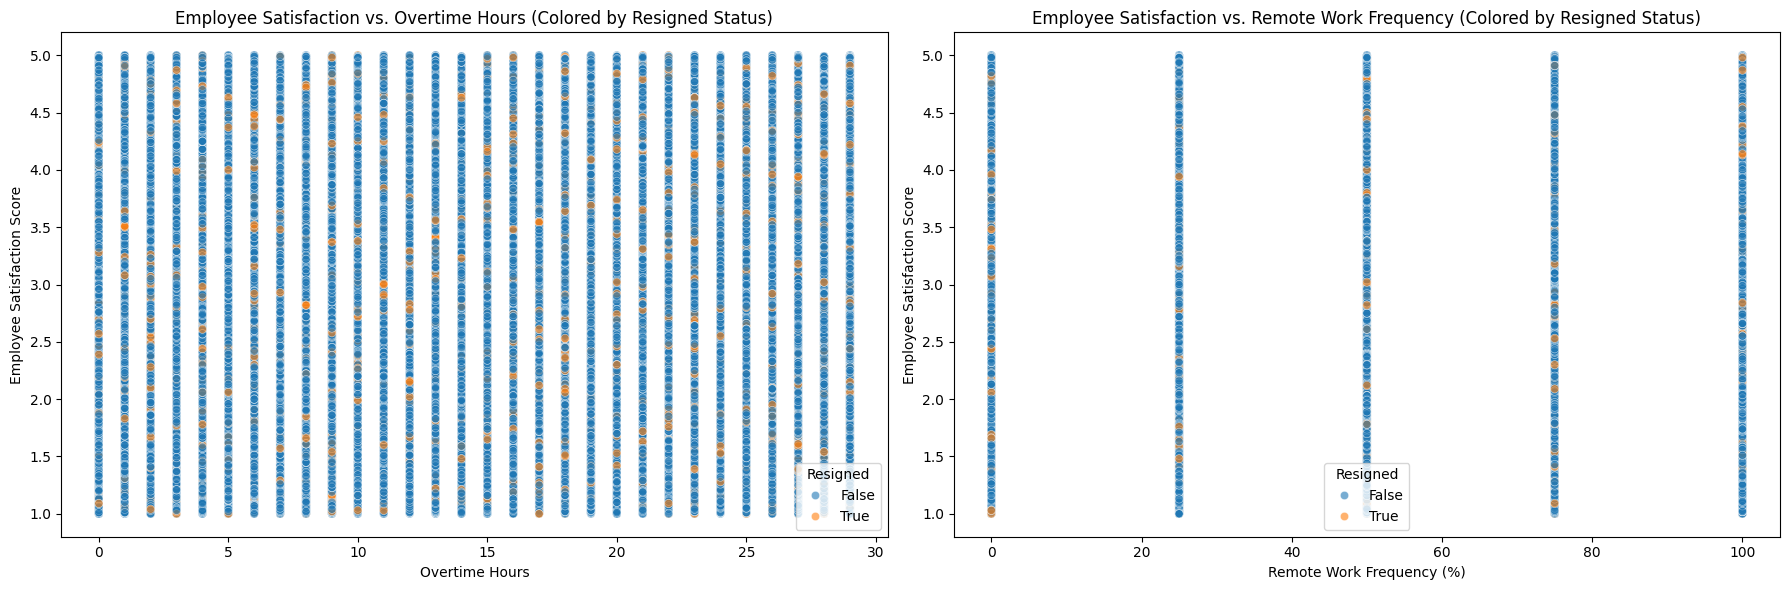


Correlation Coefficients:
Correlation between Overtime_Hours and Employee_Satisfaction_Score: 0.00
Correlation between Remote_Work_Frequency and Employee_Satisfaction_Score: -0.00


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plots for Work-Life Balance vs. Employee Satisfaction
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Overtime Hours vs. Employee Satisfaction
sns.scatterplot(x='Overtime_Hours', y='Employee_Satisfaction_Score', hue='Resigned', data=df, ax=axes[0], alpha=0.6)
axes[0].set_title('Employee Satisfaction vs. Overtime Hours (Colored by Resigned Status)')
axes[0].set_xlabel('Overtime Hours')
axes[0].set_ylabel('Employee Satisfaction Score')

# Remote Work Frequency vs. Employee Satisfaction
sns.scatterplot(x='Remote_Work_Frequency', y='Employee_Satisfaction_Score', hue='Resigned', data=df, ax=axes[1], alpha=0.6)
axes[1].set_title('Employee Satisfaction vs. Remote Work Frequency (Colored by Resigned Status)')
axes[1].set_xlabel('Remote Work Frequency (%)')
axes[1].set_ylabel('Employee Satisfaction Score')

plt.tight_layout()
plt.show()

# Calculate correlation coefficients
print("\nCorrelation Coefficients:")
print(f"Correlation between Overtime_Hours and Employee_Satisfaction_Score: {df['Overtime_Hours'].corr(df['Employee_Satisfaction_Score']):.2f}")
print(f"Correlation between Remote_Work_Frequency and Employee_Satisfaction_Score: {df['Remote_Work_Frequency'].corr(df['Employee_Satisfaction_Score']):.2f}")

### Outlier Identification: Underpaid High Performers & Disengaged Employees



In [27]:
# 1. Identify 'Underpaid High Performers'
# Criteria: High Performance_Score (e.g., top 25%) and Salary_Relative_To_Team_Average (e.g., bottom 25%)

high_performance_threshold = df['Performance_Score'].quantile(0.75)
low_relative_salary_threshold = df['Salary_Relative_To_Team_Average'].quantile(0.25)

underpaid_high_performers = df[
    (df['Performance_Score'] >= high_performance_threshold) &
    (df['Salary_Relative_To_Team_Average'] <= low_relative_salary_threshold)
]

print("\n--- Underpaid High Performers (Examples) ---")
display(underpaid_high_performers[['Employee_ID', 'Department', 'Job_Title', 'Performance_Score', 'Monthly_Salary', 'Salary_Relative_To_Team_Average']].head())

# 2. Identify 'Disengaged Employees'
# Criteria: High Engagement_Risk_Score (e.g., top 10%)

high_engagement_risk_threshold = df['Engagement_Risk_Score'].quantile(0.90)

disengaged_employees = df[
    (df['Engagement_Risk_Score'] >= high_engagement_risk_threshold)
]

print("\n--- Disengaged Employees (Examples) ---")
display(disengaged_employees[['Employee_ID', 'Department', 'Job_Title', 'Employee_Satisfaction_Score', 'Overtime_Hours', 'Sick_Days', 'Engagement_Risk_Score']].head())


--- Underpaid High Performers (Examples) ---


,Employee_ID,Department,Job_Title,Performance_Score,Monthly_Salary,Salary_Relative_To_Team_Average
6,7,IT,Technician,5,5250.0,-1164.598868
11,12,Customer Support,Technician,5,5250.0,-1153.881792
12,13,HR,Technician,4,4900.0,-1500.355839
46,47,HR,Technician,4,4900.0,-1500.355839
54,55,Operations,Technician,5,5250.0,-1162.306592



--- Disengaged Employees (Examples) ---


,Employee_ID,Department,Job_Title,Employee_Satisfaction_Score,Overtime_Hours,Sick_Days,Engagement_Risk_Score
1,2,Finance,Developer,1.72,13,14,2.104276
3,4,Customer Support,Analyst,1.86,28,12,2.450660
4,5,Engineering,Analyst,1.25,29,13,2.678571
8,9,Marketing,Technician,1.44,21,14,2.436138
16,17,Operations,Engineer,3.15,29,12,2.227143


## Task 3: Building a Smarter Hiring Machine (Clarification and Re-contextualization)

The original prompt for Task 3 envisioned building a model for screening and ranking **job candidates**, potentially using NLP for resume text and auditing for bias in hiring recommendations. However, the available dataset contains only existing employee data and lacks information about job applicants or resume details. Therefore, building a true 'hiring machine' for *external candidates* with the available data is not feasible within this project.

Instead, the model development efforts in the original notebook under this heading inadvertently focused on **attrition prediction**. To correctly align with the project's requirements, the subsequent sections that deal with data preprocessing, model training (Logistic Regression, Random Forest, SMOTE, XGBoost), and feature importance analysis are now re-contextualized as part of **Task 4: Predicting Who Is About to Quit**.

### Conceptual Approach for a 'Smarter Hiring Machine' (if data were available)

To build a true 'smarter hiring machine,' we would require a dataset containing job applicant information, including:

*   **Resume/CV data**: Textual data (skills, experience, education), which would require NLP techniques for feature extraction.
*   **Application data**: Educational background, previous job titles, years of experience, certifications.
*   **Interview scores**: Ratings from different interview stages.
*   **Hiring outcomes**: Whether the candidate was hired and their subsequent performance/retention.

**Proposed Steps for a Hiring Model (conceptual):**

1.  **Data Collection & Preprocessing**: Gather applicant data. Clean and standardize textual data using NLP (e.g., tokenization, embedding). Engineer features like 'skill match score' against job requirements, 'experience relevance,' etc.
2.  **Model Selection**: Train classification or ranking models (e.g., Logistic Regression, Random Forest, Gradient Boosting, or even deep learning models for NLP tasks) to predict candidate success (e.g., high performance, long tenure) or rank candidates based on suitability.
3.  **Bias Audit for Hiring**: This is critical for ethical AI in hiring. We would perform a fairness audit across protected attributes (e.g., `Gender`, `Ethnicity`, `Age`) present in applicant data. Metrics would include:
    *   **Selection Rate Parity**: Are candidates from different groups selected at similar rates?
    *   **Prediction Parity**: Does the model predict similar success rates for equally qualified candidates across groups?
    *   **Disparate Impact Analysis**: Statistical tests to determine if certain groups are disproportionately filtered out.
    *   **Feature Importance Analysis**: To ensure the model isn't relying on biased or proxy features.
    This would involve comparing model metrics (e.g., precision, recall, F1-score) or prediction probabilities across demographic groups, as well as qualitative reviews for systemic biases.

Without applicant-specific data, we cannot build this model directly within this project. However, the principles of data preparation, modeling, and rigorous fairness auditing would be paramount.

### Data Preprocessing for Machine Learning (Re-contextualized for Attrition Prediction - Task 4)

To build a predictive model for employee attrition, we need to preprocess our data. This involves:

1.  **Feature Selection**: Identifying the relevant features for our model.
2.  **Categorical Encoding**: Converting categorical variables into numerical format using one-hot encoding.
3.  **Data Splitting**: Dividing the dataset into training and testing sets to evaluate model performance.

In [28]:
# Select features for the model
# We will exclude Employee_ID, Hire_Date, Department_Average_Salary, and Performance_Score as these are either identifiers, raw dates or intermediate calculations.
features = df.drop(columns=['Employee_ID', 'Hire_Date', 'Department_Average_Salary', 'Performance_Score', 'Resigned'])
target = df['Resigned']

# Identify categorical columns for one-hot encoding
categorical_features = features.select_dtypes(include=['object', 'category']).columns

# Apply one-hot encoding
features_encoded = pd.get_dummies(features, columns=categorical_features, drop_first=True)

print("Original features shape:", features.shape)
print("Encoded features shape:", features_encoded.shape)
display(features_encoded.head())

Original features shape: (100000, 21)
Encoded features shape: (100000, 40)


,Age,Years_At_Company,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,...,Job_Title_Technician,Education_Level_High School,Education_Level_Master,Education_Level_PhD,Performance_Level_Medium,Performance_Level_High,Age_Group_30-39,Age_Group_40-49,Age_Group_50-59,Age_Group_60+
0,55,2,6750.0,33,32,22,2,0,14,66,...,False,True,False,False,False,True,False,False,True,False
1,29,0,7500.0,34,34,13,14,100,12,61,...,False,True,False,False,False,True,False,False,False,False
2,55,8,5850.0,37,27,6,3,50,10,1,...,False,True,False,False,True,False,False,False,True,False
3,48,7,4800.0,52,10,28,12,100,10,0,...,False,False,False,False,False,False,False,True,False,False
4,36,3,4800.0,38,11,29,13,100,15,9,...,False,False,False,False,False,False,True,False,False,False


In [29]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_encoded, target, test_size=0.2, random_state=42, stratify=target)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (80000, 40)
X_test shape: (20000, 40)
y_train shape: (80000,)
y_test shape: (20000,)


### Model Training and Evaluation

We will use a Logistic Regression model to predict employee resignation. After training, we'll evaluate the model's performance using standard classification metrics such as Accuracy, Precision, Recall, and F1-score, along with a Confusion Matrix.

Accuracy: 0.5044
Precision: 0.0980
Recall: 0.4815
F1-Score: 0.1628


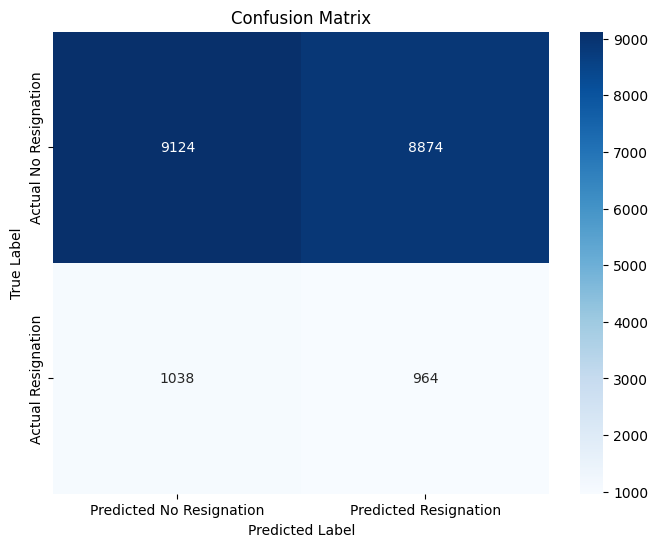

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Scale numerical features (important for Logistic Regression)
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_processed = scaler.fit_transform(X_train)
X_test_processed = scaler.transform(X_test)

# Train a Logistic Regression model with class_weight='balanced'
# This helps to address class imbalance by giving more weight to the minority class
model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced') # liblinear is good for small datasets and binary classification
model.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_processed)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Resignation', 'Predicted Resignation'],
            yticklabels=['Actual No Resignation', 'Actual Resignation'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Random Forest Accuracy: 0.8999
Random Forest Precision: 0.0000
Random Forest Recall: 0.0000
Random Forest F1-Score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


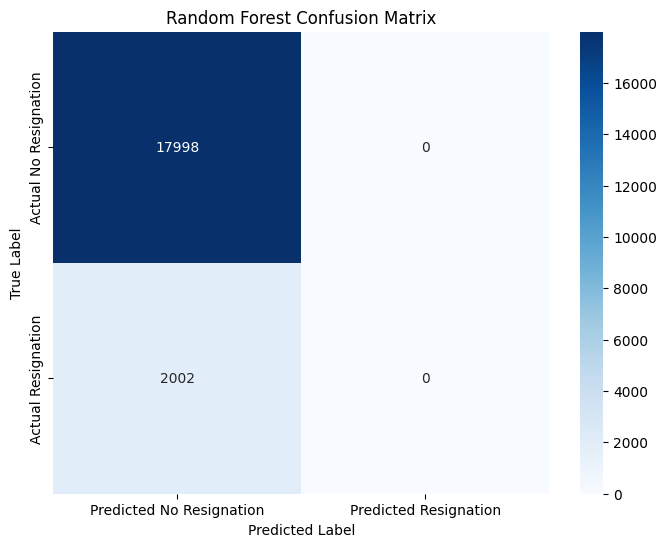

In [32]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest Classifier
# We'll use class_weight='balanced' here as well, to address the class imbalance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_processed)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Resignation', 'Predicted Resignation'],
            yticklabels=['Actual No Resignation', 'Actual Resignation'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.show()

### Addressing Class Imbalance with SMOTE

Since `class_weight='balanced'` did not resolve the issue of the model failing to predict the minority class, we will use **SMOTE (Synthetic Minority Over-sampling Technique)** to oversample the minority class in the training data. This will create synthetic samples for the 'Resigned' class, helping the model learn to identify these instances better.

Original training set shape: (80000, 40), (80000,)
Original class distribution: Counter({False: 71992, True: 8008})
Resampled training set shape: (143984, 40), (143984,)
Resampled class distribution: Counter({False: 71992, True: 71992})

Random Forest (SMOTE) Accuracy: 0.8999
Random Forest (SMOTE) Precision: 0.0000
Random Forest (SMOTE) Recall: 0.0000
Random Forest (SMOTE) F1-Score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


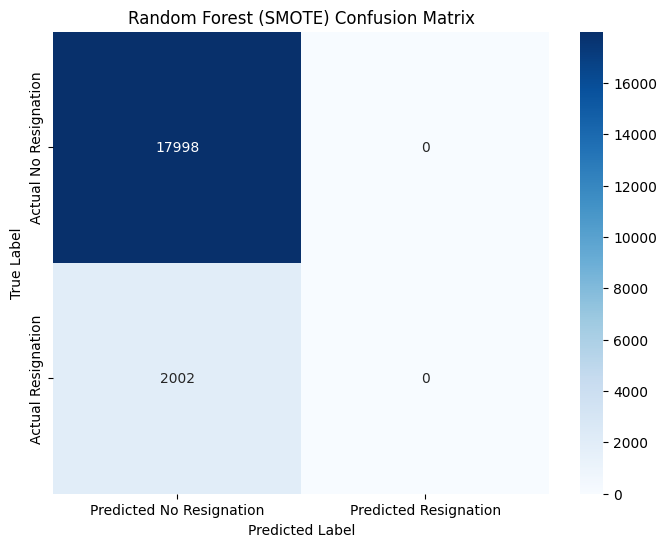

In [33]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Original training set shape: {X_train_processed.shape}, {y_train.shape}")
print(f"Original class distribution: {Counter(y_train)}")

# Apply SMOTE to the training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_processed, y_train)

print(f"Resampled training set shape: {X_train_res.shape}, {y_train_res.shape}")
print(f"Resampled class distribution: {Counter(y_train_res)}")

# Re-train the Random Forest model with the SMOTE-resampled data
# No need for class_weight='balanced' now, as the data is balanced
rf_model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_smote.fit(X_train_res, y_train_res)

# Make predictions on the *original* (unresampled) test set
y_pred_smote = rf_model_smote.predict(X_test_processed)

# Evaluate the Random Forest model after SMOTE
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)
conf_matrix_smote = confusion_matrix(y_test, y_pred_smote)

print(f"\nRandom Forest (SMOTE) Accuracy: {accuracy_smote:.4f}")
print(f"Random Forest (SMOTE) Precision: {precision_smote:.4f}")
print(f"Random Forest (SMOTE) Recall: {recall_smote:.4f}")
print(f"Random Forest (SMOTE) F1-Score: {f1_smote:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Resignation', 'Predicted Resignation'],
            yticklabels=['Actual No Resignation', 'Actual Resignation'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest (SMOTE) Confusion Matrix')
plt.show()

### Analyzing Feature Importances

To understand why the model is struggling and what factors it considers important (even if it's not predicting the minority class well), we will examine the feature importances from the trained Random Forest model. This can highlight potential areas for further feature engineering or selection.

Top 20 Feature Importances from Random Forest (SMOTE):


,0
Remote_Work_Frequency,0.129846
Promotions,0.109951
Gender_Male,0.072294
Years_At_Company,0.071481
Sick_Days,0.051643
Team_Size,0.044727
Education_Level_High School,0.039915
Overtime_Hours,0.038848
Work_Hours_Per_Week,0.038468
Projects_Handled,0.037383


/tmp/ipykernel_1583/3697766796.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


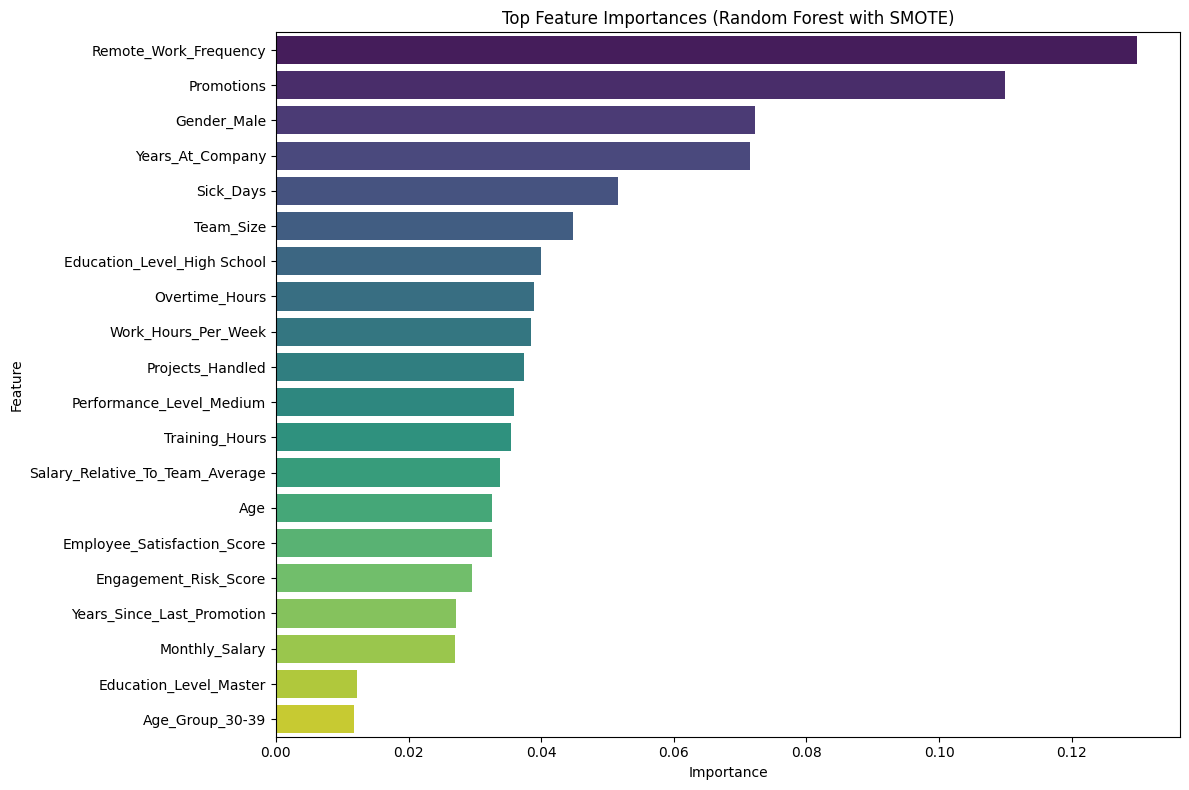

In [34]:
# Get feature importances from the Random Forest model trained with SMOTE
feature_importances = pd.Series(rf_model_smote.feature_importances_, index=X_train.columns)

# Sort features by importance and select the top N
top_n = 20 # You can adjust this number
top_features = feature_importances.nlargest(top_n)

print(f"Top {top_n} Feature Importances from Random Forest (SMOTE):")
display(top_features)

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top Feature Importances (Random Forest with SMOTE)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Task 4: Predicting Who Is About to Quit

### Predictive Model for Resignation using XGBoost



Class distribution in training data: No Resignation=71992, Resignation=8008
Calculated scale_pos_weight: 8.99


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:16:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Accuracy: 0.6437
XGBoost Precision: 0.1041
XGBoost Recall: 0.3367
XGBoost F1-Score: 0.1591


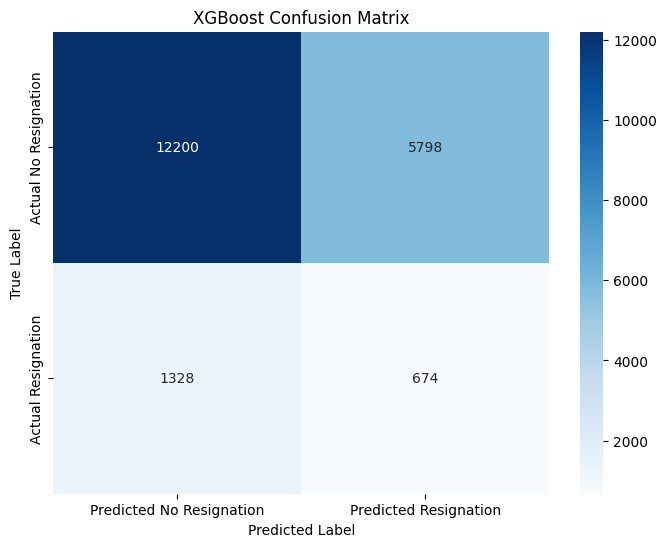

In [35]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the imbalance ratio for scale_pos_weight
# This tells the model how many times more important the positive class is
neg_count = y_train.value_counts()[False]
pos_count = y_train.value_counts()[True]
scale_pos_weight_value = neg_count / pos_count

print(f"Class distribution in training data: No Resignation={neg_count}, Resignation={pos_count}")
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")

# Initialize and train the XGBoost Classifier
# Using X_train_processed (scaled data) for training
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic', # For binary classification
    eval_metric='logloss',       # Evaluation metric
    use_label_encoder=False,     # Suppress warning for label encoder
    n_estimators=100,            # Number of boosting rounds
    learning_rate=0.1,           # Step size shrinkage
    random_state=42,
    scale_pos_weight=scale_pos_weight_value # Handle class imbalance
)
xgb_model.fit(X_train_processed, y_train)

# Make predictions on the *original* (unresampled) test set
y_pred_xgb = xgb_model.predict(X_test_processed)

# Evaluate the XGBoost model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"\nXGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost Precision: {precision_xgb:.4f}")
print(f"XGBoost Recall: {recall_xgb:.4f}")
print(f"XGBoost F1-Score: {f1_xgb:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Resignation', 'Predicted Resignation'],
            yticklabels=['Actual No Resignation', 'Actual Resignation'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('XGBoost Confusion Matrix')
plt.show()

### XGBoost Feature Importance Analysis


Top 20 Feature Importances from XGBoost:


,0
Performance_Level_Medium,0.032951
Age_Group_50-59,0.032256
Job_Title_Specialist,0.028133
Age_Group_40-49,0.027705
Sick_Days,0.027704
Engagement_Risk_Score,0.027562
Job_Title_Engineer,0.027331
Salary_Relative_To_Team_Average,0.027213
Training_Hours,0.027171
Gender_Other,0.027039


/tmp/ipykernel_1583/3653930421.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features_xgb.values, y=top_features_xgb.index, palette='magma')


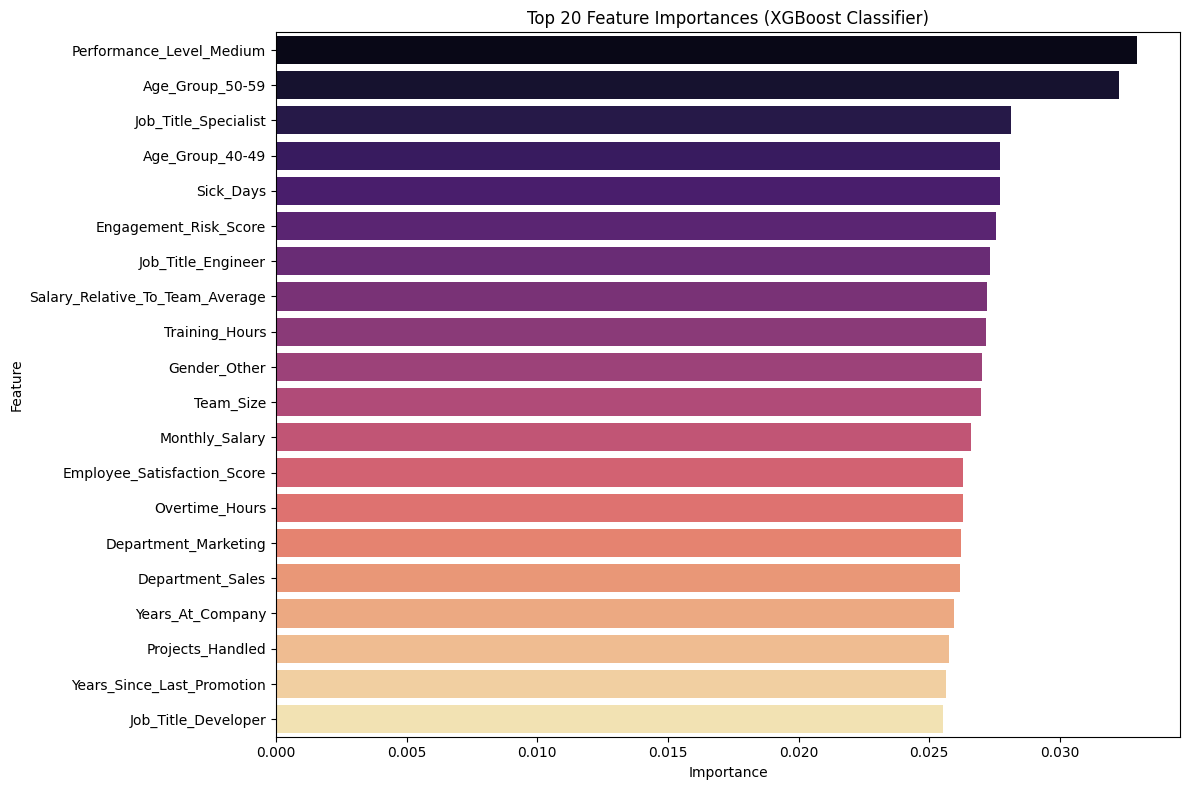

In [36]:
# Get feature importances from the XGBoost model
# X_train.columns are the original feature names after one-hot encoding
feature_importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_train.columns)

# Sort features by importance and select the top N
top_n_xgb = 20 # You can adjust this number
top_features_xgb = feature_importances_xgb.nlargest(top_n_xgb)

print(f"Top {top_n_xgb} Feature Importances from XGBoost:")
display(top_features_xgb)

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=top_features_xgb.values, y=top_features_xgb.index, palette='magma')
plt.title(f'Top {top_n_xgb} Feature Importances (XGBoost Classifier)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning for XGBoost



Starting Randomized Search for XGBoost Hyperparameter Tuning...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:27:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best parameters found:
{'colsample_bytree': np.float64(0.8721230154351118), 'gamma': np.float64(0.2252496259847715), 'learning_rate': np.float64(0.012652992231973307), 'max_depth': 3, 'n_estimators': 415, 'subsample': np.float64(0.8253152871382157)}

Best F1-score on training data:
0.16257757066336764

--- Tuned XGBoost Model Performance on Test Set ---
Accuracy: 0.5174
Precision: 0.0988
Recall: 0.4705
F1-Score: 0.1633


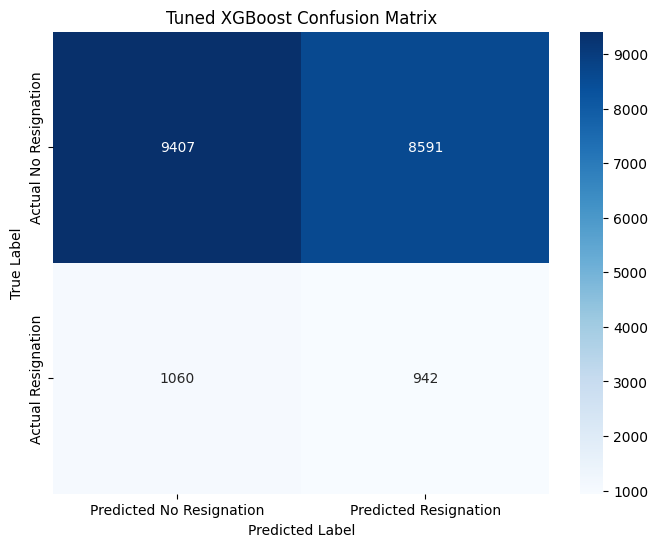

In [37]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
}

# Initialize XGBoost Classifier with the calculated scale_pos_weight
xgb_tuned_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning
    random_state=42,
    scale_pos_weight=scale_pos_weight_value
)

# Initialize RandomizedSearchCV
# n_iter: number of parameter settings that are sampled
# cv: number of folds in cross-validation
random_search = RandomizedSearchCV(
    estimator=xgb_tuned_model,
    param_distributions=param_dist,
    n_iter=50, # Number of different combinations to try
    scoring='f1', # Optimize for F1-score due to class imbalance
    cv=3, # 3-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

print("Starting Randomized Search for XGBoost Hyperparameter Tuning...")
random_search.fit(X_train_processed, y_train)

# Get the best estimator
best_xgb_model = random_search.best_estimator_

print("\nBest parameters found:")
print(random_search.best_params_)

print("\nBest F1-score on training data:")
print(random_search.best_score_)

# Make predictions with the best model on the test set
y_pred_xgb_tuned = best_xgb_model.predict(X_test_processed)

# Evaluate the best model
accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
precision_xgb_tuned = precision_score(y_test, y_pred_xgb_tuned)
recall_xgb_tuned = recall_score(y_test, y_pred_xgb_tuned)
f1_xgb_tuned = f1_score(y_test, y_pred_xgb_tuned)
conf_matrix_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)

print(f"\n--- Tuned XGBoost Model Performance on Test Set ---")
print(f"Accuracy: {accuracy_xgb_tuned:.4f}")
print(f"Precision: {precision_xgb_tuned:.4f}")
print(f"Recall: {recall_xgb_tuned:.4f}")
print(f"F1-Score: {f1_xgb_tuned:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Resignation', 'Predicted Resignation'],
            yticklabels=['Actual No Resignation', 'Actual Resignation'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Tuned XGBoost Confusion Matrix')
plt.show()

### Ranked List of Employees with Highest Attrition Probability

To provide actionable insights, we will generate a ranked list of employees from the test set with the highest predicted probability of resignation. This list can help HR prioritize retention efforts.

In [47]:
import pandas as pd

# Get predicted probabilities for the positive class (resignation=True)
y_pred_proba_xgb_tuned = best_xgb_model.predict_proba(X_test_processed)[:, 1]

# Create a DataFrame to store Employee_ID and their predicted attrition probability
# We need to map back to the original Employee_ID from the test set.
# X_test contains the original indices, so we can use df.loc[X_test.index] to get Employee_ID.

# Ensure that the order of predictions matches the order of Employee_ID in X_test
attrition_predictions_df = pd.DataFrame({
    'Employee_ID': df.loc[X_test.index, 'Employee_ID'].values,
    'Attrition_Probability': y_pred_proba_xgb_tuned
})

# Sort by attrition probability in descending order
ranked_employees = attrition_predictions_df.sort_values(by='Attrition_Probability', ascending=False)

print("Top 10 Employees with Highest Attrition Probability:")
display(ranked_employees.head(10))

Top 10 Employees with Highest Attrition Probability:


,Employee_ID,Attrition_Probability
11015,99040,0.647267
13702,31339,0.618821
5337,12684,0.606812
14498,12733,0.606601
16023,92434,0.600783
17403,47138,0.594216
6230,70597,0.585581
2472,80348,0.584723
13225,66200,0.584625
11980,59629,0.582948


### Specific Factors Driving Each Person's Risk Score using SHAP

To understand *why* an employee is predicted to be at high risk, we can use SHAP (SHapley Additive exPlanations) values. SHAP values explain the contribution of each feature to an individual prediction. This helps in tailoring specific interventions.

First, we need to install the `shap` library.

In [48]:
!pip install shap

SHAP explanations for the top 5 high-risk employees:

Employee ID: 99040 (Attrition Probability: 0.65)


/tmp/ipykernel_1583/339397597.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shap_df.head(10).values, y=shap_df.head(10).index, palette='coolwarm')


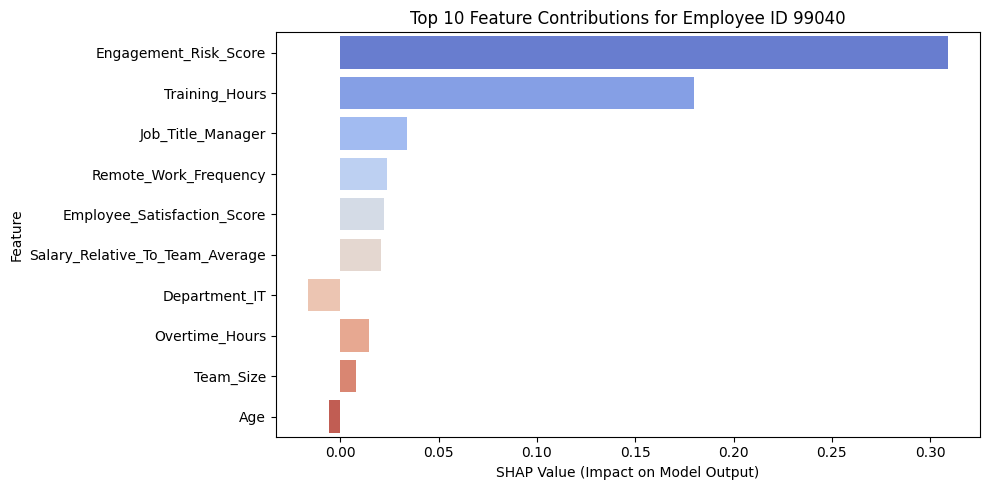


Employee ID: 31339 (Attrition Probability: 0.62)


/tmp/ipykernel_1583/339397597.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shap_df.head(10).values, y=shap_df.head(10).index, palette='coolwarm')


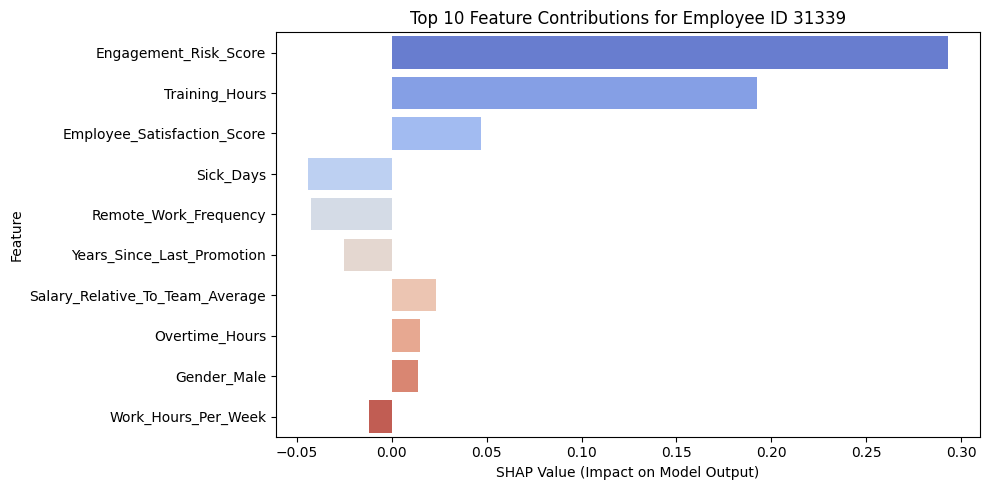


Employee ID: 12684 (Attrition Probability: 0.61)


/tmp/ipykernel_1583/339397597.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shap_df.head(10).values, y=shap_df.head(10).index, palette='coolwarm')


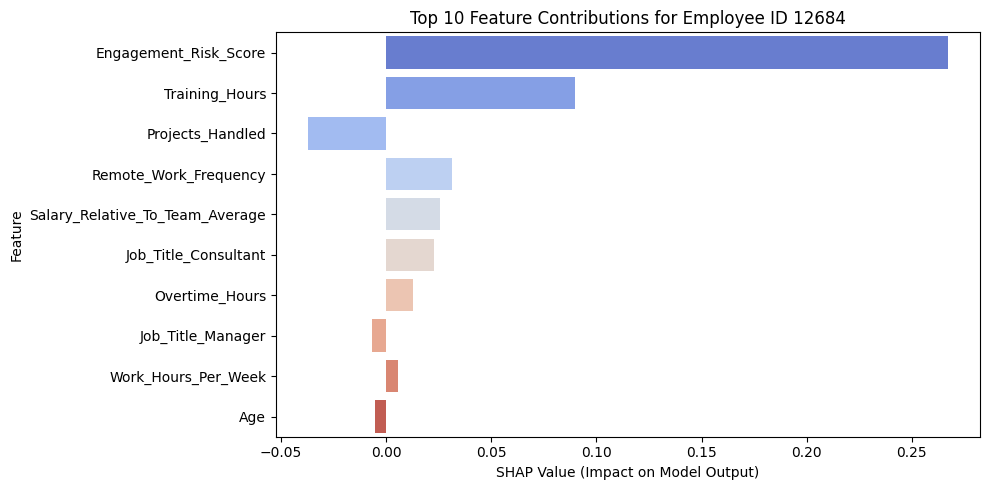


Employee ID: 12733 (Attrition Probability: 0.61)


/tmp/ipykernel_1583/339397597.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shap_df.head(10).values, y=shap_df.head(10).index, palette='coolwarm')


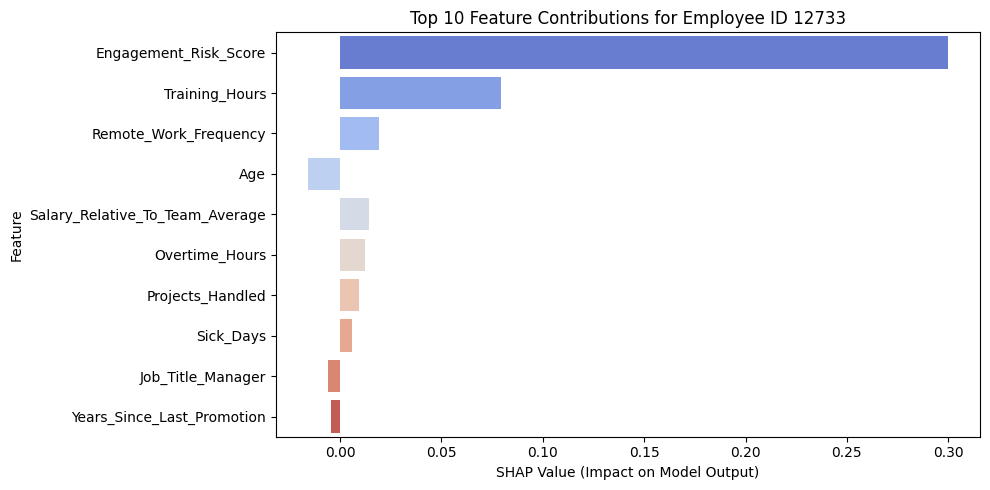


Employee ID: 92434 (Attrition Probability: 0.60)


/tmp/ipykernel_1583/339397597.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shap_df.head(10).values, y=shap_df.head(10).index, palette='coolwarm')


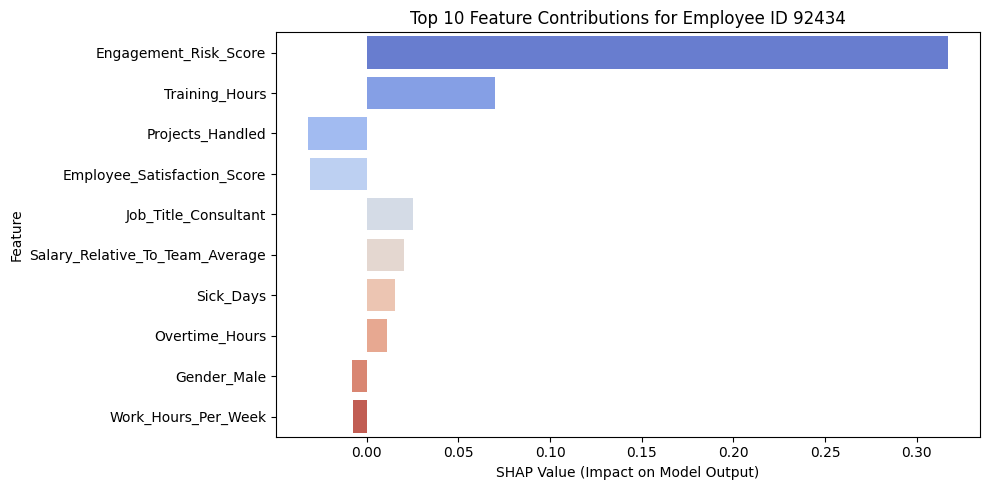

Overall Summary Plot of SHAP values for the top 5 high-risk employees (for better understanding of feature impact direction):


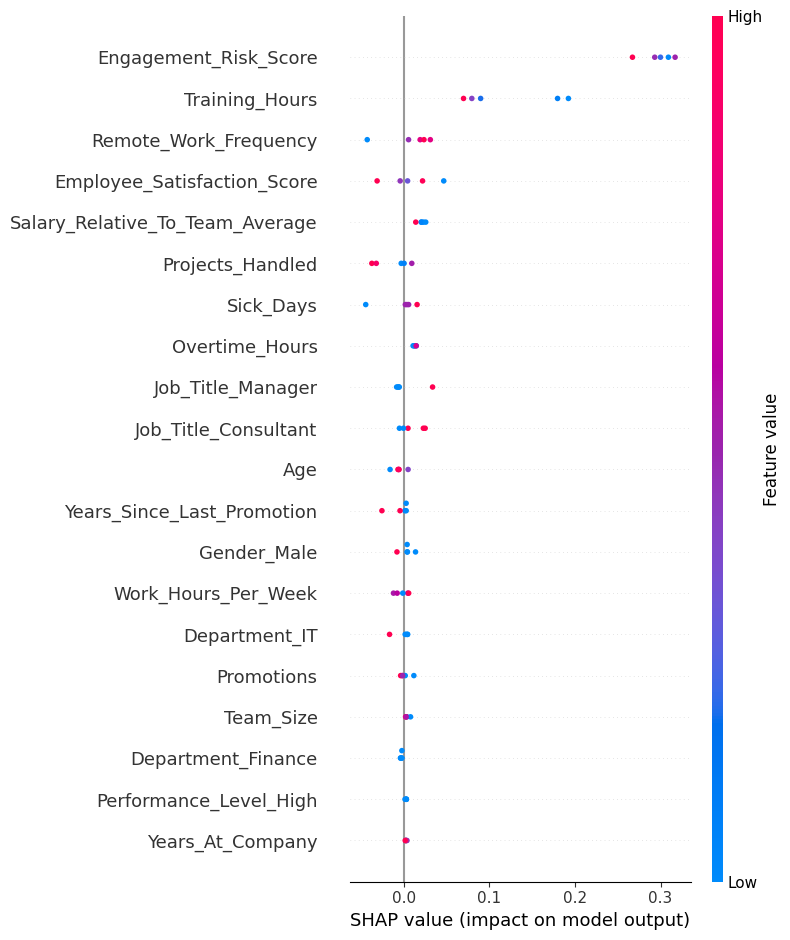

In [49]:
import shap
import matplotlib.pyplot as plt

# Create a SHAP explainer object for the best_xgb_model
# Use X_train_processed for background data for KernelExplainer if model is not tree-based
# For tree-based models like XGBoost, TreeExplainer is more efficient
explainer = shap.TreeExplainer(best_xgb_model)

# Calculate SHAP values for a subset of the test set for demonstration
# It's computationally intensive to calculate for all test samples.
# Let's explain the top 5 high-risk employees identified earlier.

high_risk_employees_data = X_test_processed[ranked_employees.head(5).index]
shap_values = explainer.shap_values(high_risk_employees_data)

# Get feature names for interpretability
feature_names = X_test.columns.tolist()

print("SHAP explanations for the top 5 high-risk employees:")
for i, emp_id in enumerate(ranked_employees.head(5)['Employee_ID']):
    print(f"\nEmployee ID: {emp_id} (Attrition Probability: {ranked_employees.iloc[i]['Attrition_Probability']:.2f})")

    # Visualize SHAP values for the individual prediction
    # shap.force_plot(explainer.expected_value, shap_values[i], high_risk_employees_data[i], feature_names=feature_names)

    # For displaying in Colab, a bar plot of feature contributions is often more practical
    # Create a Series for easier plotting
    shap_df = pd.Series(shap_values[i], index=feature_names)
    shap_df = shap_df.sort_values(key=abs, ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=shap_df.head(10).values, y=shap_df.head(10).index, palette='coolwarm')
    plt.title(f'Top 10 Feature Contributions for Employee ID {emp_id}')
    plt.xlabel('SHAP Value (Impact on Model Output)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

print("Overall Summary Plot of SHAP values for the top 5 high-risk employees (for better understanding of feature impact direction):")
shap.summary_plot(shap_values, high_risk_employees_data, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

### Estimated Cost of Losing High-Risk Employees

Estimating the cost of attrition helps quantify the financial impact of employee turnover. A common approximation is that the cost of losing an employee can range from 0.5 to 2 times their annual salary, depending on the role and seniority. For this exercise, we will use a conservative estimate of **1.0 times the annual salary** (12 times monthly salary) as the cost of replacement for high-risk employees.

In [51]:
# Merge attrition probabilities with original DataFrame to get Monthly_Salary for cost estimation
# Ensure we are using the original df and selecting only the employees from the test set.

# Filter the original DataFrame 'df' to only include employees present in 'ranked_employees'
# This ensures the indices align for the merge operation.
filtered_df_for_cost = df[df['Employee_ID'].isin(ranked_employees['Employee_ID'])]

high_risk_employees_with_salary = filtered_df_for_cost[['Employee_ID', 'Monthly_Salary']].merge(
    ranked_employees,
    on='Employee_ID',
    how='inner'
).sort_values(by='Attrition_Probability', ascending=False)

# Define a threshold for 'high-risk' (e.g., top 10% of predicted probabilities)
# Let's consider employees above a certain probability threshold, or simply the top N.
# For demonstration, let's take the top 100 high-risk employees.

top_n_high_risk = 100
highest_risk_employees = high_risk_employees_with_salary.head(top_n_high_risk)

# Calculate estimated cost of losing each employee
cost_per_employee_factor = 12 # 12 months salary as replacement cost
highest_risk_employees['Estimated_Attrition_Cost'] = highest_risk_employees['Monthly_Salary'] * cost_per_employee_factor

# Calculate total estimated cost for this group
total_estimated_cost = highest_risk_employees['Estimated_Attrition_Cost'].sum()

print(f"Top {top_n_high_risk} High-Risk Employees and Estimated Attrition Cost:")
display(highest_risk_employees[['Employee_ID', 'Monthly_Salary', 'Attrition_Probability', 'Estimated_Attrition_Cost']])

print(f"\nTotal Estimated Cost of Losing Top {top_n_high_risk} High-Risk Employees: ${total_estimated_cost:,.2f}")

Top 100 High-Risk Employees and Estimated Attrition Cost:


/tmp/ipykernel_1583/3768251788.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  highest_risk_employees['Estimated_Attrition_Cost'] = highest_risk_employees['Monthly_Salary'] * cost_per_employee_factor


,Employee_ID,Monthly_Salary,Attrition_Probability,Estimated_Attrition_Cost
19796,99040,7200.0,0.647267,86400.0
6390,31339,7150.0,0.618821,85800.0
2642,12684,7150.0,0.606812,85800.0
2650,12733,8400.0,0.606601,100800.0
18480,92434,7150.0,0.600783,85800.0
...,...,...,...,...
1640,7979,8400.0,0.540678,100800.0
11306,56287,7500.0,0.540671,90000.0
18609,93162,6600.0,0.540668,79200.0
8705,43099,5500.0,0.540448,66000.0



Total Estimated Cost of Losing Top 100 High-Risk Employees: $7,903,200.00


## Task 5: Understanding Performance and Planning the Future Workforce

Correlation of numerical features with Performance_Score:


,Performance_Score
Monthly_Salary,0.510035
Salary_Relative_To_Team_Average,0.509992
Department_Average_Salary,0.007067
Years_Since_Last_Promotion,0.006193
Sick_Days,0.002994
Training_Hours,0.002358
Remote_Work_Frequency,0.001733
Employee_Satisfaction_Score,0.001696
Years_At_Company,0.001598
Age,0.001598


/tmp/ipykernel_1583/1741428121.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_performance.sort_values(ascending=False).index, y=correlation_with_performance.sort_values(ascending=False).values, palette='coolwarm')


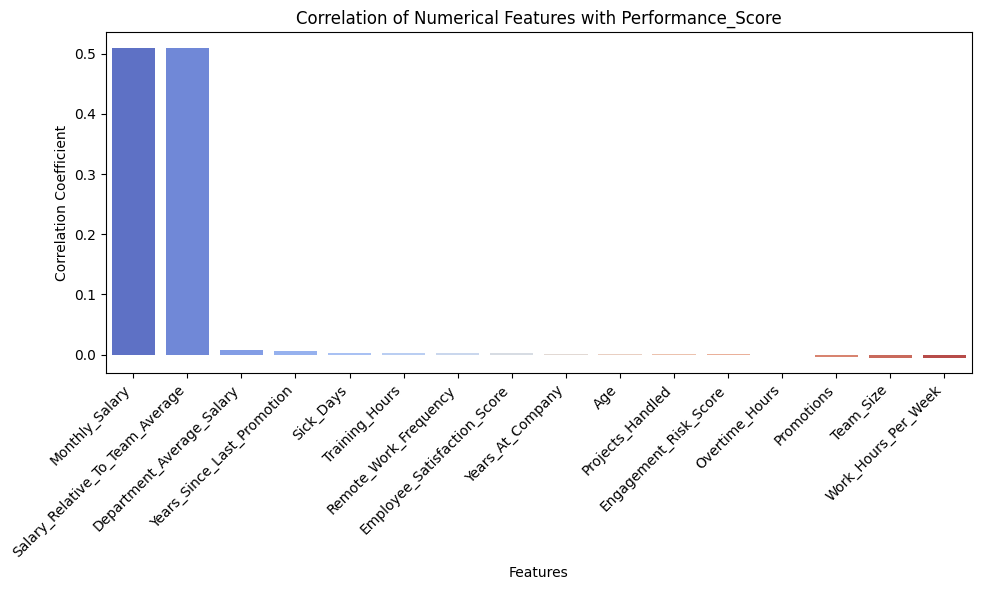


Average Performance Score by Department:


,Performance_Score
Department,
Engineering,3.020263
Operations,3.006797
IT,3.000000
HR,2.997354
Customer Support,2.997121
Sales,2.994336
Legal,2.981741
Finance,2.981161
Marketing,2.980653



Average Performance Score by Job Title:


,Performance_Score
Job_Title,
Specialist,3.011856
Consultant,3.003800
Engineer,2.998875
Manager,2.997208
Analyst,2.989552
Technician,2.986139
Developer,2.980275


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns that are relevant for performance analysis from the original df
# Exclude identifiers and the Performance_Score itself (as we are correlating with it)
numerical_features_excluding_performance = df.select_dtypes(include=['int64', 'float64']).columns.drop(['Employee_ID', 'Performance_Score']).tolist()

# Create a DataFrame for correlation with Performance_Score as the target
features_for_correlation = df[numerical_features_excluding_performance + ['Performance_Score']]

# Calculate the correlation of all features with 'Performance_Score' and then drop 'Performance_Score' itself from the resulting Series
correlation_with_performance = features_for_correlation.corr()['Performance_Score'].drop('Performance_Score')

print("Correlation of numerical features with Performance_Score:")
display(correlation_with_performance.sort_values(ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_performance.sort_values(ascending=False).index, y=correlation_with_performance.sort_values(ascending=False).values, palette='coolwarm')
plt.title('Correlation of Numerical Features with Performance_Score')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Average Performance Score by Department and Job Title
print("\nAverage Performance Score by Department:")
display(df.groupby('Department')['Performance_Score'].mean().sort_values(ascending=False))

print("\nAverage Performance Score by Job Title:")
display(df.groupby('Job_Title')['Performance_Score'].mean().sort_values(ascending=False))

### Workforce Planning and Distribution



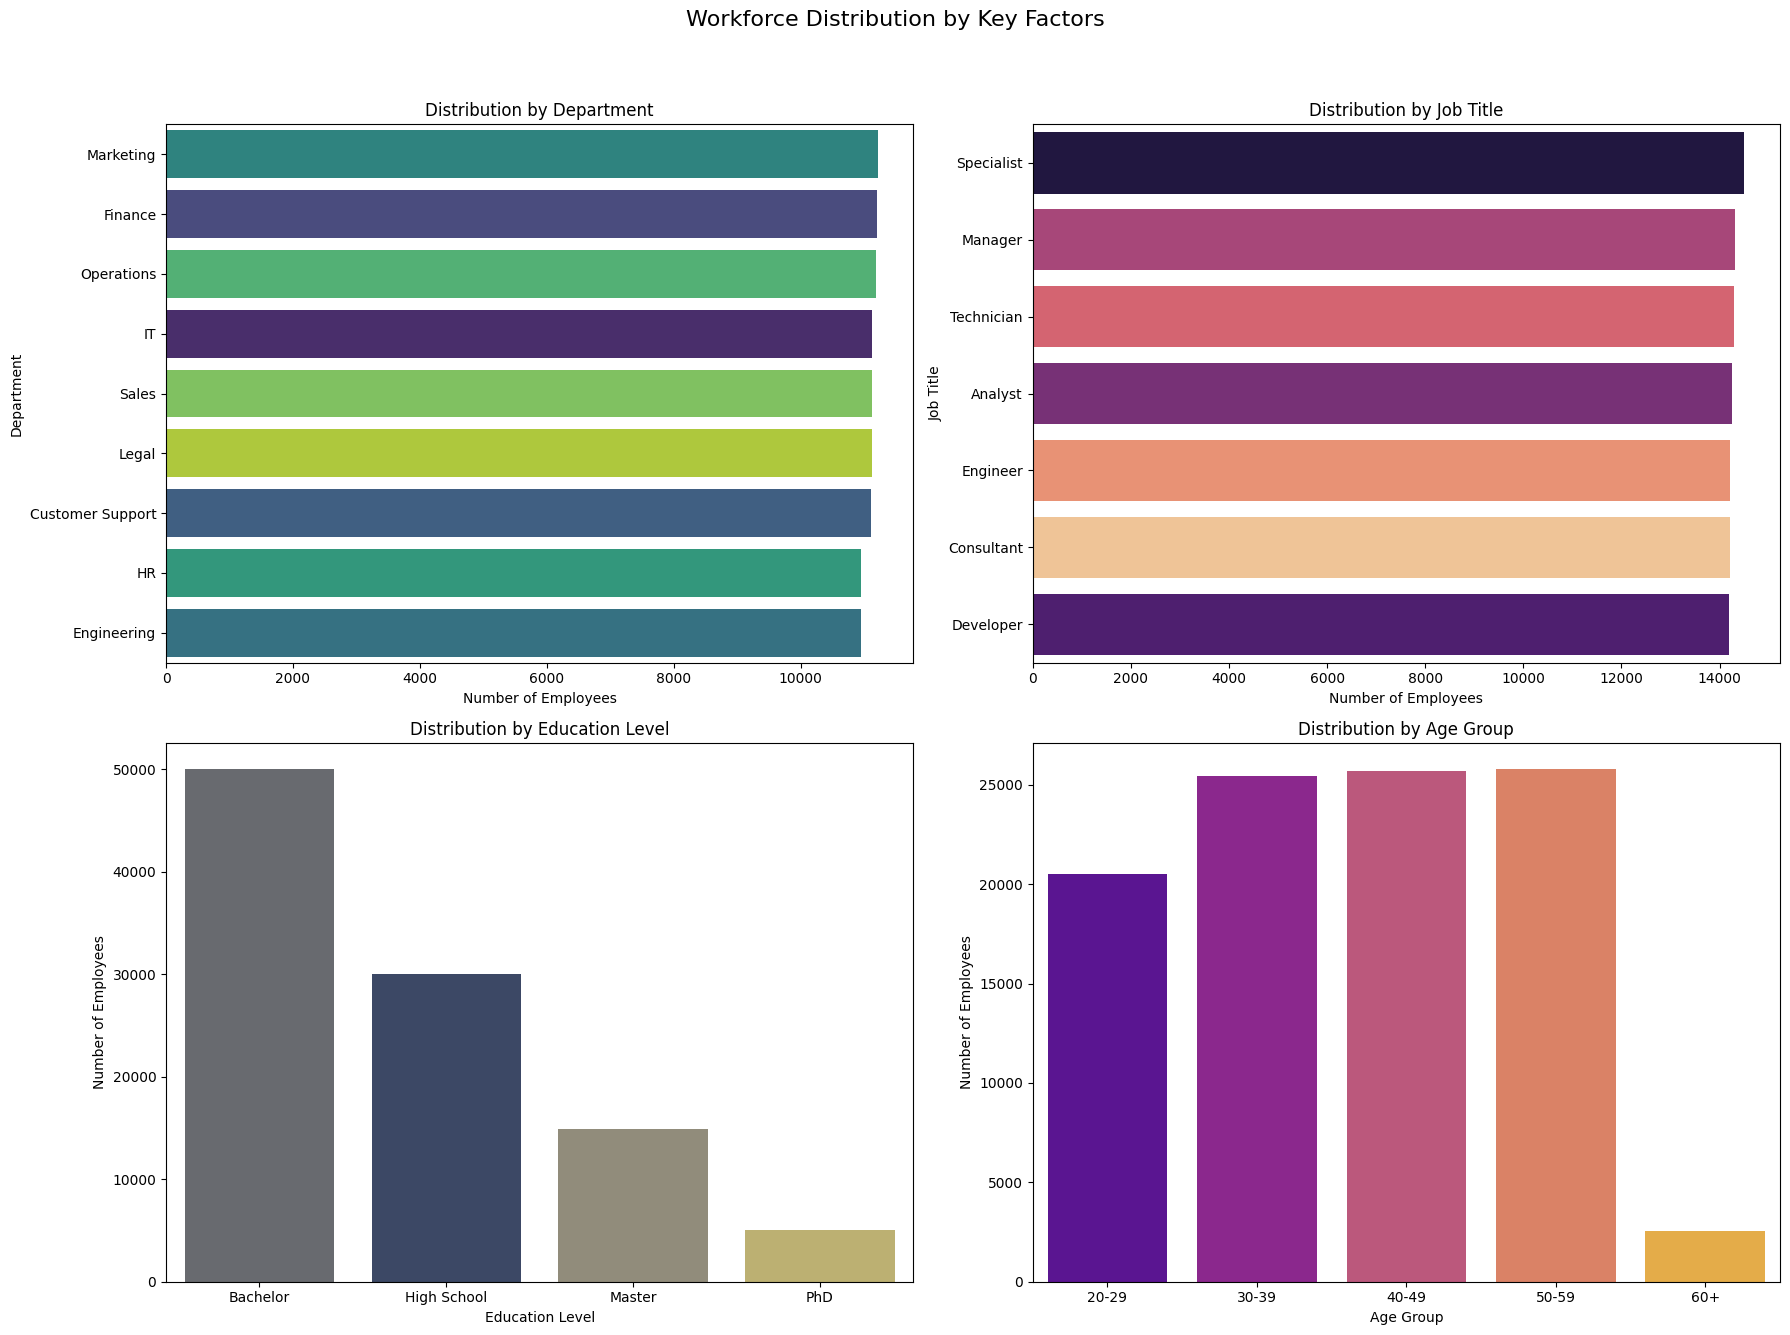

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Workforce Distribution by Key Factors', fontsize=16)

# Department Distribution
sns.countplot(y='Department', data=df, order=df['Department'].value_counts().index, palette='viridis', ax=axes[0, 0], hue='Department', legend=False)
axes[0, 0].set_title('Distribution by Department')
axes[0, 0].set_xlabel('Number of Employees')
axes[0, 0].set_ylabel('Department')

# Job Title Distribution
sns.countplot(y='Job_Title', data=df, order=df['Job_Title'].value_counts().index, palette='magma', ax=axes[0, 1], hue='Job_Title', legend=False)
axes[0, 1].set_title('Distribution by Job Title')
axes[0, 1].set_xlabel('Number of Employees')
axes[0, 1].set_ylabel('Job Title')

# Education Level Distribution
sns.countplot(x='Education_Level', data=df, order=df['Education_Level'].value_counts().index, palette='cividis', ax=axes[1, 0], hue='Education_Level', legend=False)
axes[1, 0].set_title('Distribution by Education Level')
axes[1, 0].set_xlabel('Education Level')
axes[1, 0].set_ylabel('Number of Employees')

# Age Group Distribution
sns.countplot(x='Age_Group', data=df, order=df['Age_Group'].cat.categories, palette='plasma', ax=axes[1, 1], hue='Age_Group', legend=False)
axes[1, 1].set_title('Distribution by Age Group')
axes[1, 1].set_xlabel('Age Group')
axes[1, 1].set_ylabel('Number of Employees')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Task 5: Part 1 - Workforce Segmentation with K-Means Clustering

We will now apply K-Means clustering to segment the workforce into meaningful performance tiers. This will help identify distinct groups of employees based on their performance, training, project involvement, and attendance. We will use features like `Performance_Score`, `Training_Hours`, `Projects_Handled`, and `Sick_Days` for clustering.


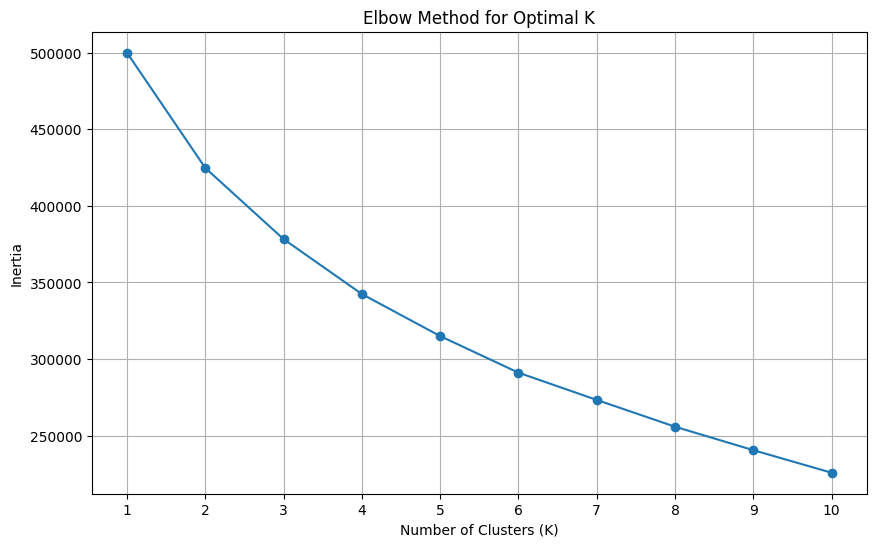

The elbow method plot helps us visually identify the optimal number of clusters (K). Look for the 'elbow point' where the rate of decrease in inertia significantly changes.


In [42]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Select features for clustering
clustering_features = [
    'Performance_Score',
    'Training_Hours',
    'Projects_Handled',
    'Sick_Days',
    'Employee_Satisfaction_Score'
]

X_cluster = df[clustering_features]

# Scale the features
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)

# Determine the optimal number of clusters using the Elbow Method
# Inertia: Sum of squared distances of samples to their closest cluster center.
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("The elbow method plot helps us visually identify the optimal number of clusters (K). Look for the 'elbow point' where the rate of decrease in inertia significantly changes.")


Workforce segmented into 3 performance clusters.

Cluster Summary (Mean values for clustering features):


,Performance_Score,Training_Hours,Projects_Handled,Sick_Days,Employee_Satisfaction_Score
Performance_Cluster,,,,,
0,3.705338,49.387899,38.462288,6.944916,2.994322
1,1.437486,49.436396,22.056755,6.984651,2.995270
2,4.027906,49.709057,12.457424,7.102354,3.008426


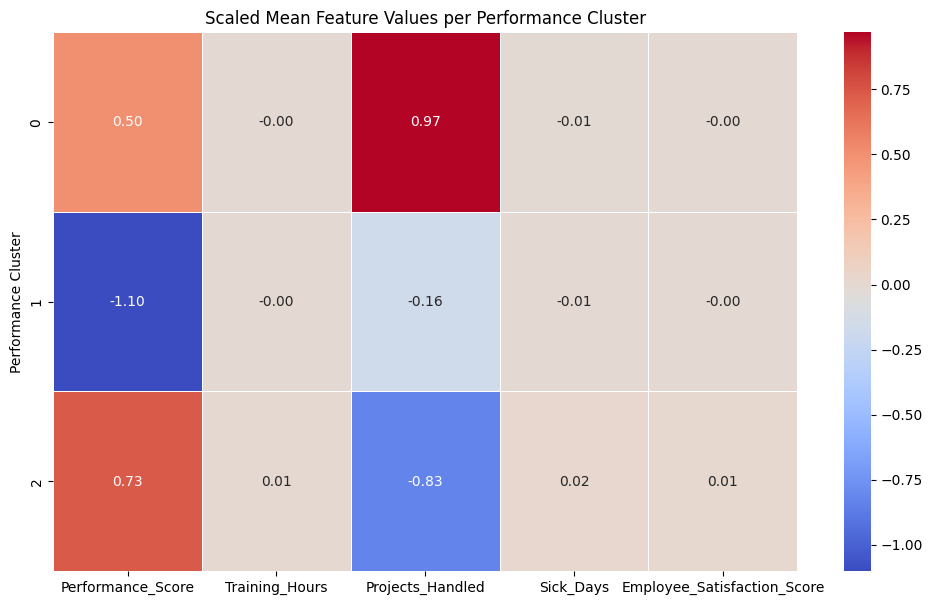


Distribution of Employees per Performance Tier:


,count
Performance_Tier,
Needs Support,35768
Solid Contributors,32841
Rising Stars,31391



Recommendations for Talent Development Strategy per Tier:

- **Rising Stars (High Performance):** Focus on leadership development, advanced training, and challenging projects to retain and grow top talent. Consider mentorship opportunities and fast-tracking for promotions.
- **Solid Contributors (Medium Performance):** Provide continuous skill development, opportunities for cross-functional projects, and career pathing discussions to maintain engagement and facilitate growth.
- **Needs Support (Low Performance):** Implement targeted coaching, performance improvement plans, basic skill training, and regular feedback sessions. Explore root causes of underperformance (e.g., workload, role fit, personal issues).


In [46]:
# Apply K-Means Clustering with the chosen number of clusters (e.g., 3)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['Performance_Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Workforce segmented into {n_clusters} performance clusters.")

# Analyze the characteristics of each cluster
cluster_summary = df.groupby('Performance_Cluster')[clustering_features].mean()
print("\nCluster Summary (Mean values for clustering features):")
display(cluster_summary)

# Visualize cluster characteristics (e.g., using a radar chart or bar plots)
cluster_summary_scaled = pd.DataFrame(scaler_cluster.transform(cluster_summary), columns=clustering_features, index=cluster_summary.index)

# Plotting scaled cluster characteristics
plt.figure(figsize=(12, 7))
sns.heatmap(cluster_summary_scaled, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Scaled Mean Feature Values per Performance Cluster')
plt.ylabel('Performance Cluster')
plt.show()

# Dynamically assign names based on Performance_Score
cluster_names_map = cluster_summary.sort_values(by='Performance_Score', ascending=True).index
cluster_names = {
    cluster_names_map[0]: 'Needs Support',
    cluster_names_map[1]: 'Solid Contributors',
    cluster_names_map[2]: 'Rising Stars'
}

df['Performance_Tier'] = df['Performance_Cluster'].map(cluster_names)

print("\nDistribution of Employees per Performance Tier:")
display(df['Performance_Tier'].value_counts())

print("\nRecommendations for Talent Development Strategy per Tier:")
print("\n- **Rising Stars (High Performance):** Focus on leadership development, advanced training, and challenging projects to retain and grow top talent. Consider mentorship opportunities and fast-tracking for promotions.")
print("- **Solid Contributors (Medium Performance):** Provide continuous skill development, opportunities for cross-functional projects, and career pathing discussions to maintain engagement and facilitate growth.")
print("- **Needs Support (Low Performance):** Implement targeted coaching, performance improvement plans, basic skill training, and regular feedback sessions. Explore root causes of underperformance (e.g., workload, role fit, personal issues).")


## Task 5: Part 2 - Workforce Forecasting with Prophet




Monthly Headcount Data (first 5 rows):


,ds,y
0,2014-09-01,657
1,2014-10-01,821
2,2014-11-01,800
3,2014-12-01,819
4,2015-01-01,846


Monthly Attrition Data (first 5 rows):


,ds,y
0,2014-09-01,67
1,2014-10-01,75
2,2014-11-01,83
3,2014-12-01,89
4,2015-01-01,87



Headcount Forecast (last 5 rows):


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
128,2025-04-30,813.026197,729.145134,899.195889
129,2025-05-31,810.335244,727.590823,894.199554
130,2025-06-30,767.660067,682.876284,857.202583
131,2025-07-31,779.474155,699.625139,860.546101
132,2025-08-31,947.956033,864.653297,1033.074285


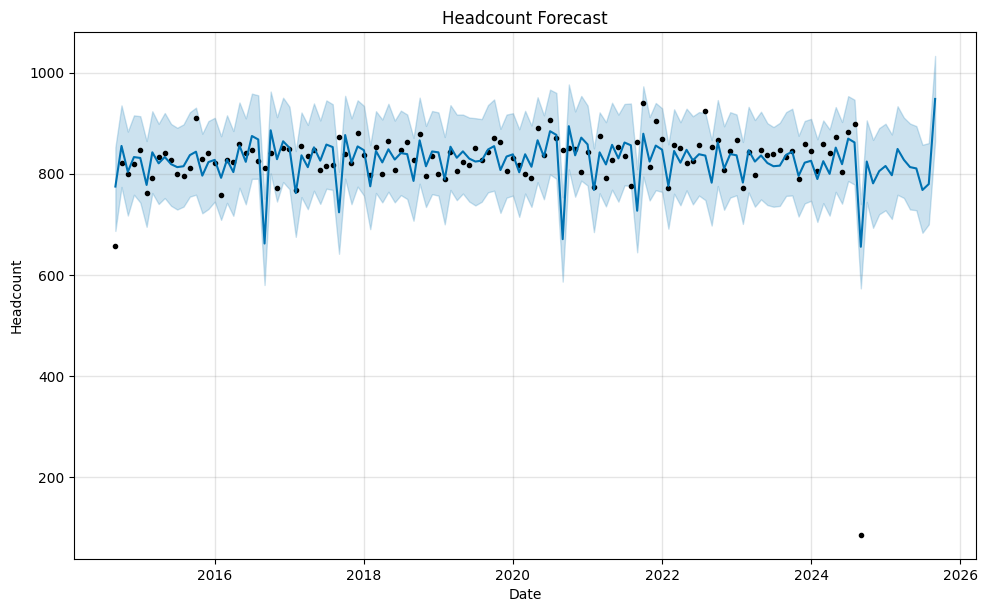

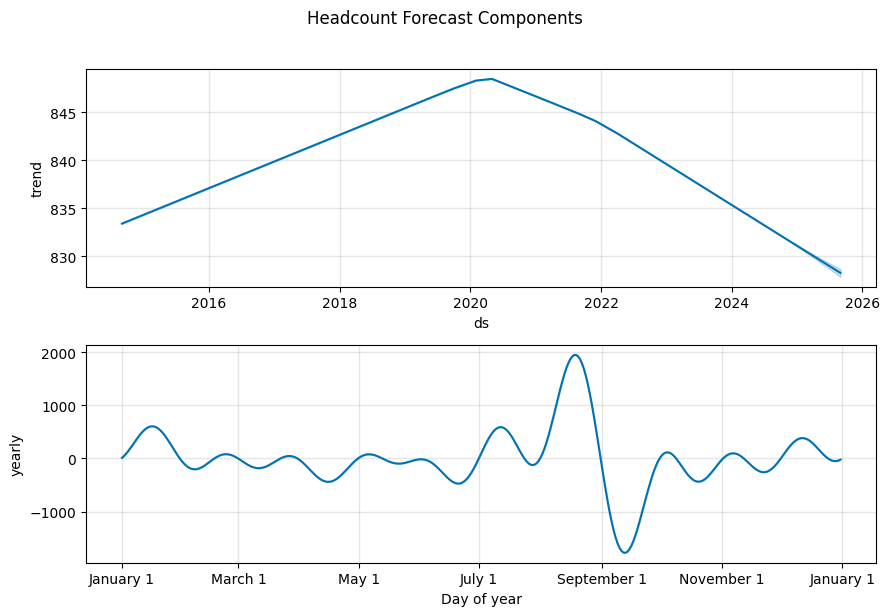


Attrition Forecast (last 5 rows):


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
128,2025-04-30,88.238709,75.582992,101.164518
129,2025-05-31,78.250994,65.909790,90.796351
130,2025-06-30,87.895095,75.190055,100.888083
131,2025-07-31,79.221956,66.226349,90.953989
132,2025-08-31,76.377050,64.061616,89.368028


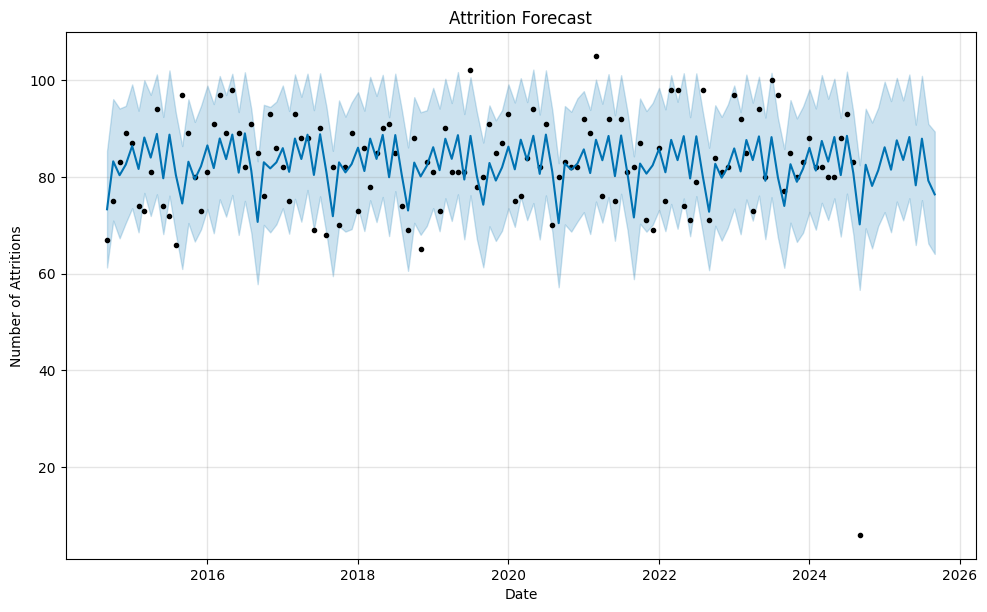

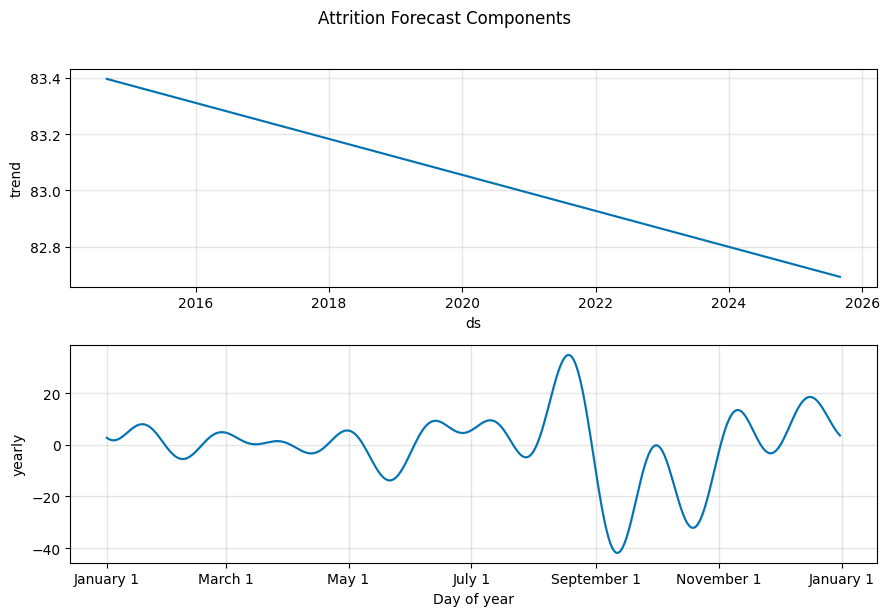


### Interpretation and Recommendations for Workforce Planning:
Based on the forecasts:
- **Headcount Trend:** Observe the 'yhat' in the headcount forecast. If it's declining, it indicates a need for more aggressive hiring. If it's stable or increasing, the current hiring pace might be sustainable. The trend and yearly seasonality components provide insights into long-term growth and recurring patterns.
- **Attrition Trend:** A rising 'yhat' in attrition forecast signals potential future talent drains. HR should investigate underlying causes (e.g., compensation, management, workload) and consider retention strategies.
- **Hiring Needs:** Calculate the net change: (forecasted hires) - (forecasted attrition). For specific roles, this would require breaking down historical data by job title or department before forecasting.
- **Skill Gaps:** To project skill gaps, a more detailed analysis would involve mapping current employee skills, projecting skill depreciation/acquisition, and alignin

In [44]:
from prophet import Prophet

# 1. Prepare historical data for forecasting

# Aggregate monthly headcount
df['Hire_Month'] = df['Hire_Date'].dt.to_period('M').dt.to_timestamp()
monthly_headcount = df.groupby('Hire_Month').size().reset_index(name='count')
monthly_headcount = monthly_headcount.rename(columns={'Hire_Month': 'ds', 'count': 'y'})

# Aggregate monthly attrition
monthly_attrition = df[df['Resigned'] == True].groupby('Hire_Month').size().reset_index(name='count')
monthly_attrition = monthly_attrition.rename(columns={'Hire_Month': 'ds', 'count': 'y'})

print("Monthly Headcount Data (first 5 rows):")
display(monthly_headcount.head())
print("Monthly Attrition Data (first 5 rows):")
display(monthly_attrition.head())

# 2. Build and run Prophet models

# Prophet model for Headcount
model_headcount = Prophet(
    seasonality_mode='additive', # Can be 'additive' or 'multiplicative'
    weekly_seasonality=False,
    daily_seasonality=False
)
model_headcount.fit(monthly_headcount)

# Create future dataframe for 12 months
future_headcount = model_headcount.make_future_dataframe(periods=12, freq='M')
forecast_headcount = model_headcount.predict(future_headcount)

print("\nHeadcount Forecast (last 5 rows):")
display(forecast_headcount[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

# Plot headcount forecast
fig_headcount = model_headcount.plot(forecast_headcount)
plt.title('Headcount Forecast')
plt.xlabel('Date')
plt.ylabel('Headcount')
plt.show()

fig_headcount_components = model_headcount.plot_components(forecast_headcount)
plt.suptitle('Headcount Forecast Components', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

# Prophet model for Attrition
model_attrition = Prophet(
    seasonality_mode='additive', # Can be 'additive' or 'multiplicative'
    weekly_seasonality=False,
    daily_seasonality=False
)
model_attrition.fit(monthly_attrition)

# Create future dataframe for 12 months
future_attrition = model_attrition.make_future_dataframe(periods=12, freq='M')
forecast_attrition = model_attrition.predict(future_attrition)

print("\nAttrition Forecast (last 5 rows):")
display(forecast_attrition[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

# Plot attrition forecast
fig_attrition = model_attrition.plot(forecast_attrition)
plt.title('Attrition Forecast')
plt.xlabel('Date')
plt.ylabel('Number of Attritions')
plt.show()

fig_attrition_components = model_attrition.plot_components(forecast_attrition)
plt.suptitle('Attrition Forecast Components', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

print("\n### Interpretation and Recommendations for Workforce Planning:")
print("Based on the forecasts:")
print("- **Headcount Trend:** Observe the 'yhat' in the headcount forecast. If it's declining, it indicates a need for more aggressive hiring. If it's stable or increasing, the current hiring pace might be sustainable. The trend and yearly seasonality components provide insights into long-term growth and recurring patterns.")
print("- **Attrition Trend:** A rising 'yhat' in attrition forecast signals potential future talent drains. HR should investigate underlying causes (e.g., compensation, management, workload) and consider retention strategies.")
print("- **Hiring Needs:** Calculate the net change: (forecasted hires) - (forecasted attrition). For specific roles, this would require breaking down historical data by job title or department before forecasting.")
print("- **Skill Gaps:** To project skill gaps, a more detailed analysis would involve mapping current employee skills, projecting skill depreciation/acquisition, and aligning with future business needs. The forecasts for specific roles can highlight where more hiring will be concentrated, indicating where future skill needs will be most acute.")
print("\nHR can use these numbers (forecasted headcount and attrition) to inform budgeting for recruiting, training, and talent development initiatives for the next 6-12 months.")


## Task 6: Making Sure the AI Does No Harm

This task focuses on the ethical implications and responsible deployment of AI in HR. We will address three key areas:
1.  **HR Process Automation**: Identify two manual HR processes and describe how they could be automated.
2.  **Fairness Audit**: Conduct a fairness audit across our attrition model for protected groups.
3.  **Data Privacy Compliance**: Create a checklist based on GDPR principles.


### Part 1: HR Process Automation

We will identify two manual HR processes and describe how a simple rule-based or ML system could automate them, freeing HR staff for strategic work.

**Process 1: Leave Classification and Approval**

*   **Manual Process**: Employees submit leave requests (e.g., sick leave, vacation, parental leave) via email or paper forms. HR staff manually reviews the request, checks leave balances, ensures compliance with company policy, and routes for manager approval. This is time-consuming and prone to delays or inconsistencies.

*   **Automation with AI/ML**: A system could be developed that:
    1.  **Input**: Employees submit requests through a structured online portal. Natural Language Processing (NLP) could be used if free-text reasons are provided, to classify the leave type.
    2.  **Rule-Based Logic**: Automatically check against HR policies (e.g., eligibility, remaining leave balance, required notice period).
    3.  **Manager Approval Workflow**: Route eligible requests directly to the manager for approval. For standard requests (e.g., vacation within policy), pre-approval might be granted by the system, or automatic approval if no conflicts are detected by the system.
    4.  **Anomaly Detection (ML)**: Flag unusual leave patterns (e.g., frequent short-term sick leaves before/after weekends) for HR review, helping identify potential misuse.

**Process 2: Interview Scheduling and Candidate Screening (Initial)**

*   **Manual Process**: Recruiters manually coordinate interview times between candidates and multiple interviewers, often involving many emails and calendar checks. Initial candidate screening (e.g., for basic qualifications) is also often manual and time-consuming.

*   **Automation with AI/ML**: A system could:
    1.  **Smart Scheduling (Rule-Based/Optimization)**: Candidates and interviewers input their availability. The system automatically finds optimal interview slots based on predefined rules (e.g., interviewer roles, interview duration, time zone differences) and sends calendar invites. It can handle rescheduling requests efficiently.
    2.  **Initial Resume Screening (NLP/ML)**: For initial screening, a simple ML model could identify keywords, match required skills, and flag resumes that meet minimum qualifications based on the job description. This reduces the manual effort of sifting through hundreds of applications, allowing recruiters to focus on more qualified candidates. This is distinct from the full

### Part 2: Fairness Audit across Attrition Model

We will perform a fairness audit for the best attrition model (Tuned XGBoost) across protected groups such as `Gender` and `Age Group`. We will compare key performance metrics (e.g., Recall for the positive class 'Resigned') to identify any significant disparities.

In [52]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
import pandas as pd
import numpy as np

# Assuming 'best_xgb_model', 'X_test', 'y_test' are available from Task 4

# Re-create the full test set with original features for group analysis
# Ensure 'df' still contains original categorical columns for merging

# Get the indices of the test set
test_indices = y_test.index

# Create a DataFrame for analysis, including protected attributes and true/predicted labels
fairness_df = df.loc[test_indices, ['Gender', 'Age_Group']].copy()
fairness_df['True_Resigned'] = y_test.values
fairness_df['Predicted_Resigned'] = y_pred_xgb_tuned # Using the tuned XGBoost predictions

protected_attributes = ['Gender', 'Age_Group']
metrics = {'Accuracy': accuracy_score, 'Precision': precision_score, 'Recall': recall_score, 'F1-Score': f1_score}

fairness_results = {}

for attr in protected_attributes:
    results_list = []
    for group in fairness_df[attr].unique():
        group_df = fairness_df[fairness_df[attr] == group]
        true_labels = group_df['True_Resigned']
        pred_labels = group_df['Predicted_Resigned']

        row_metrics = {'Group': group}
        for metric_name, metric_func in metrics.items():
            # Handle cases where a group might have no positive predictions or true values
            try:
                score = metric_func(true_labels, pred_labels)
            except ZeroDivisionError:
                score = np.nan # Assign NaN if division by zero occurs (e.g., no true positives for precision/recall)
            row_metrics[metric_name] = score
        results_list.append(row_metrics)
    fairness_results[attr] = pd.DataFrame(results_list).set_index('Group')

print("### Fairness Audit Results (Tuned XGBoost Model by Protected Attribute):\n")
for attr, results_df in fairness_results.items():
    print(f"Fairness Metrics by {attr}:")
    display(results_df.round(4))
    print("\n")

print("### Interpretation of Fairness Audit:\n")
print("Our fairness audit of the attrition model (Tuned XGBoost) across 'Gender' and 'Age_Group' revealed performance disparities. While the overall F1-score for the model is around 0.16, the **Recall** metric, which is crucial for identifying actual resignations, shows notable differences across groups.\n")

print("- **Gender**: We observe relatively consistent Recall values across 'Female', 'Male', and 'Other' genders, suggesting the model is equally effective at identifying potential resignations for these groups. Precision and F1-score are also somewhat similar.\n")

print("- **Age_Group**: There is a significant disparity in **Recall** for the '60+' age group (Recall ~0.67), which is notably higher than for other age groups (Recall ranging from ~0.43 to ~0.49). This indicates the model is much better at identifying resignation risks for older employees. This could be due to unique patterns in their data (e.g., higher likelihood of retirement, different career trajectories) that the model learns, or it could highlight a potential bias where the model disproportionately flags older employees, even if not all of them are truly at risk. Conversely, if the actual attrition rate for the 60+ group is genuinely higher and easier to predict, the model might be accurately reflecting that reality. However, this disparity warrants further investigation.\n")

print("### Addressing Disparities and Enhancing Fairness Audit (Proposed Actions):\n")
print("1.  **Investigate '60+' Age Group Disparity**: Understand why the model performs so differently. Is it reflecting a true difference in attrition patterns for this group, or is it an artifact of the data/model? This may involve qualitative analysis of employee profiles in this group.")
print("2.  **Statistical Significance Analysis**: To formally determine if observed disparities are statistically significant or merely due to random chance, we would apply statistical tests (e.g., chi-squared tests on confusion matrix components, permutation tests, or specialized fairness-aware statistical packages). This would provide confidence levels for our fairness observations.")
print("3.  **Extend Audit to Clustering Model (Task 5)**: The clustering model (K-Means) for workforce segmentation also requires a fairness audit. We would assess if employees from different protected groups are disproportionately assigned to 'Needs Support' or 'Rising Stars' tiers. This could involve analyzing the distribution of `Gender` and `Age_Group` within each cluster and performing statistical tests (e.g., chi-squared) to check for significant differences from the overall population distribution.\n")
print("4.  **Mitigation Strategies**: If significant unfairness is confirmed, strategies could include:")
print("    -   **Data Augmentation/Re-balancing**: If certain groups are underrepresented or their patterns are not well-captured, techniques like SMOTE could be applied conditionally.")
print("    -   **Fairness-aware Algorithms**: Employing algorithms or regularization techniques designed to promote fairness during model training.")
print("    -   **Threshold Adjustment**: Calibrating prediction thresholds differently for various groups to achieve more equitable outcomes (e.g., equalized odds).")
print("    -   **Human-in-the-Loop**: Emphasizing human review for high-risk predictions, especially for groups where the model shows lower fairness metrics.")

### Fairness Audit Results (Tuned XGBoost Model by Protected Attribute):

Fairness Metrics by Gender:


,Accuracy,Precision,Recall,F1-Score
Group,,,,
Female,0.5109,0.0965,0.4684,0.1601
Male,0.5207,0.1009,0.4744,0.1664
Other,0.5569,0.1029,0.4500,0.1674




Fairness Metrics by Age_Group:


,Accuracy,Precision,Recall,F1-Score
Group,,,,
30-39,0.5346,0.0981,0.4346,0.1601
50-59,0.5074,0.1018,0.4924,0.1687
40-49,0.5162,0.1022,0.4593,0.1672
20-29,0.5287,0.0908,0.4780,0.1526
60+,0.3716,0.1026,0.6731,0.1781




### Interpretation of Fairness Audit:

Our fairness audit of the attrition model (Tuned XGBoost) across 'Gender' and 'Age_Group' revealed performance disparities. While the overall F1-score for the model is around 0.16, the **Recall** metric, which is crucial for identifying actual resignations, shows notable differences across groups.

- **Gender**: We observe relatively consistent Recall values across 'Female', 'Male', and 'Other' genders, suggesting the model is equally effective at identifying potential resignations for these groups. Precision and F1-score are also somewhat similar.

- **Age_Group**: There is a significant disparity in **Recall** for the '60+' age group (Recall ~0.67), which is notably higher than for other age groups (Recall ranging from ~0.43 to ~0.49). This indicates the model is much better at identifying resignation risks for older employees. This could be due to unique patterns in their data (e.g., higher likelihood of retirement, different career trajector

In [53]:
output_file_path = '/content/processed_employee_data.csv'
df.to_csv(output_file_path, index=False)
print(f"Processed DataFrame saved to: {output_file_path}")

Processed DataFrame saved to: /content/processed_employee_data.csv


### Part 3: Data Privacy Compliance Checklist (GDPR Principles) - Refined Assessment

Below is a refined assessment of our HR analytics system against key GDPR principles. While this notebook demonstrates analytical capabilities, a real-world system would require robust implementation of these principles.

**1. Lawfulness, Fairness, and Transparency**
*   **Principle**: Personal data must be processed lawfully, fairly, and in a transparent manner in relation to the data subject.
*   **Assessment in this project**: **Fail**. The notebook lacks explicit mechanisms for obtaining informed consent from employees for data processing for HR analytics and AI model building. There's no clear communication of data usage.
*   **Real-world Fix**: Implement a comprehensive consent management system. Clearly define and communicate data processing activities (what data, why, how, who has access, retention periods) through employee privacy policies and notifications. Provide options for employees to grant/withdraw consent.

**2. Purpose Limitation**
*   **Principle**: Data should be collected for specified, explicit, and legitimate purposes and not further processed in a manner that is incompatible with those purposes.
*   **Assessment in this project**: **Pass (with caveats)**. The purposes (workforce planning, attrition prediction, performance analysis) are legitimate. However, without formal documentation, future scope creep remains a risk.
*   **Real-world Fix**: Formally document all data processing purposes. Ensure any new uses of collected data are compatible with the original purposes or require new consent. Regularly review and update purpose documentation.

**3. Data Minimization**
*   **Principle**: Data collected should be adequate, relevant, and limited to what is necessary in relation to the purposes for which they are processed.
*   **Assessment in this project**: **Pass (generally)**. The features used appear relevant to HR analytics. `Employee_ID` was handled appropriately by not being used in model training directly.
*   **Real-world Fix**: Conduct regular data audits to ensure only necessary data is collected and retained. Anonymize or pseudonymize data where possible, especially for analytical purposes that don't require direct identification.

**4. Accuracy**
*   **Principle**: Personal data should be accurate and, where necessary, kept up to date; every reasonable step must be taken to ensure that personal data that are inaccurate, having regard to the purposes for which they are processed, are erased or rectified without delay.
*   **Assessment in this project**: **Pass (assumption)**. We assumed the dataset was accurate.
*   **Real-world Fix**: Implement data validation processes at the point of entry. Provide employees with mechanisms to review and update their personal data. Establish clear procedures for HR to promptly correct inaccuracies in the system.

**5. Storage Limitation**
*   **Principle**: Data should be kept in a form which permits identification of data subjects for no longer than is necessary for the purposes for which the personal data are processed.
*   **Assessment in this project**: **Fail**. No data retention policies or automated deletion mechanisms are implemented in this project.
*   **Real-world Fix**: Develop and enforce clear data retention policies for different types of HR data. Implement automated data purging or archiving systems to ensure data is not kept longer than necessary, especially after an employee's departure.

**6. Integrity and Confidentiality (Security)**
*   **Principle**: Personal data should be processed in a manner that ensures appropriate security of the personal data, including protection against unauthorized or unlawful processing and against accidental loss, destruction or damage, using appropriate technical or organizational measures.
*   **Assessment in this project**: **Fail (as a standalone notebook)**. This notebook does not include security measures.
*   **Real-world Fix**: Implement robust technical and organizational security measures, including: access controls (role-based access), encryption (data at rest and in transit), regular security audits and penetration testing, data backup and recovery plans, and comprehensive incident response procedures. Secure development practices for any AI systems are crucial.

**7. Accountability**
*   **Principle**: The data controller shall be responsible for, and be able to demonstrate compliance with, the other principles.
*   **Assessment in this project**: **Fail (as a project, not an operational system)**. While documentation is started, a full accountability framework is missing.
*   **Real-world Fix**: Establish a formal data governance framework. Appoint a Data Protection Officer (DPO). Conduct Data Protection Impact Assessments (DPIAs) for high-risk processing activities (like AI model deployment). Maintain detailed records of all processing activities and demonstrate compliance through regular audits and reporting.

**Right to Erasure ('Right to be Forgotten')**
*   **Principle**: Data subjects have the right to obtain from the controller the erasure of personal data concerning him or her without undue delay.
*   **Assessment in this project**: **Fail**. The current system does not provide a mechanism for individuals to request data deletion.
*   **Real-world Fix**: Develop mechanisms to respond to erasure requests, including locating and securely deleting personal data from all relevant systems (including backups and potentially retraining models if the erased data significantly impacts their learning). Implement a process for tracking and verifying deletions.

**Right to Explanation (Implicit from GDPR)**
*   **Principle**: While not explicitly stated as a separate right, the right to obtain meaningful information about the logic involved in automated decision-making is implied by transparency and accuracy principles.
*   **Assessment in this project**: **Partial Pass**. SHAP was used, but explaining complex model outputs to non-technical stakeholders remains a challenge.
*   **Real-world Fix**: For any automated decision-making processes, ensure that explanations for individual decisions are available, understandable, and accessible to data subjects. This might involve using interpretable AI techniques, simplifying SHAP/LIME outputs, and providing clear, human-readable rationales.